<a href="https://colab.research.google.com/github/kgenticia-a11y/Aura/blob/main/Algo_with_Python1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2933/3591917666.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start= "2016-01-01", end="2026-08-05")
[*********************100%***********************]  4 of 4 completed


Text(0, 0.5, 'Closing Price($)')

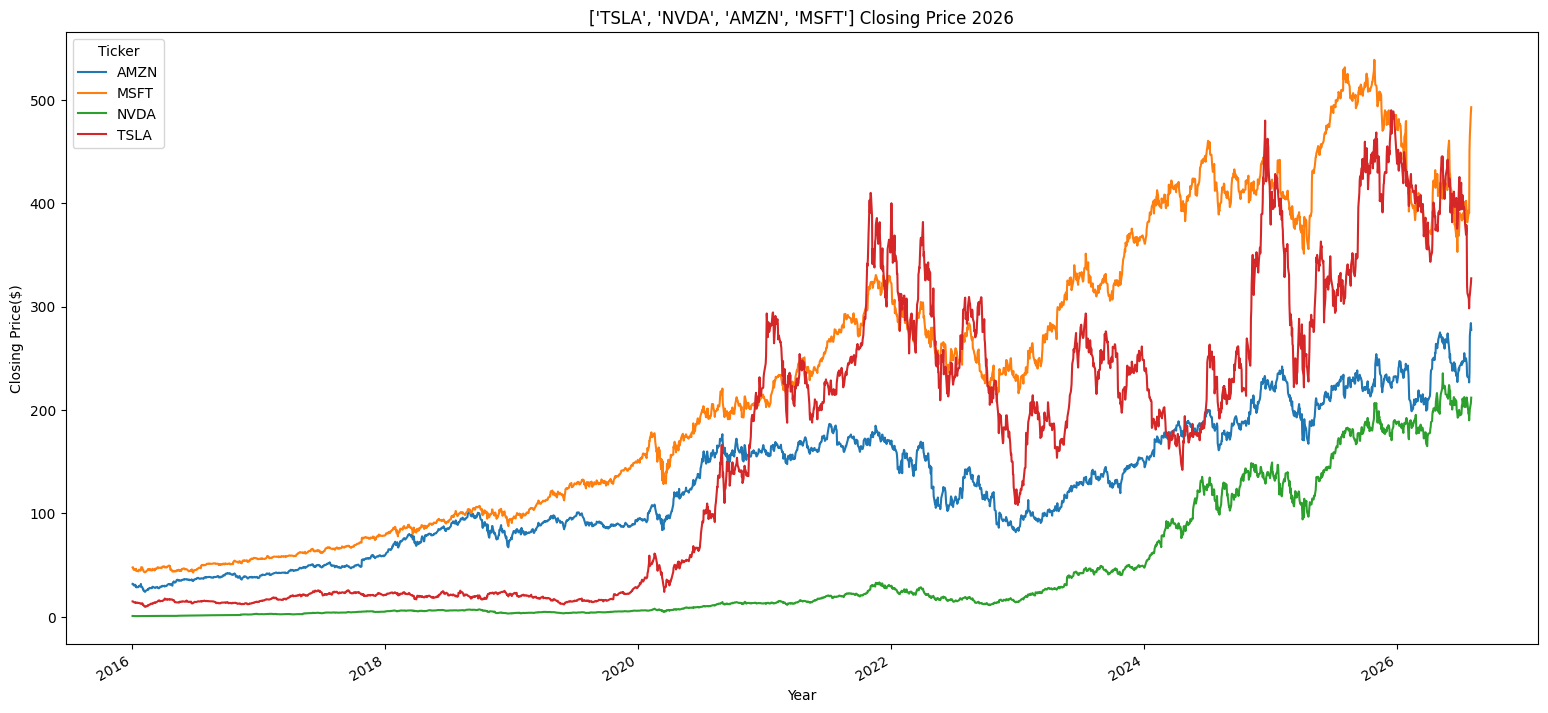

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# !pip install pandas_ta
# !pip install ccxt

tickers = ["TSLA" ,"NVDA", "AMZN",'MSFT']

data = yf.download(tickers, start= "2016-01-01", end="2026-08-05")

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

data.to_csv('data/tickers_daily.csv')
data['Close'].plot(figsize=(19,9),title=(f'{tickers} Closing Price 2026'))
plt.xlabel('Year')
plt.ylabel('Closing Price($)')

In [2]:
data = pd.read_csv('data/tickers_daily.csv', header=[0, 1], index_col=0, parse_dates=True)
# print(data.tail())

data = data.ffill() # forward fill missing data
data = data.dropna()# remove missing data rows
print(data.isnull().sum())

data.to_csv('data/tickers_daily.csv')
# The line below caused the issue, as it reloaded the CSV without MultiIndex headers.
# data = pd.read_csv('data/tickers_daily.csv')
# To ensure the MultiIndex is preserved after writing to CSV, reload it correctly.
data = pd.read_csv('data/tickers_daily.csv', header=[0, 1], index_col=0, parse_dates=True)

Price   Ticker
Close   AMZN      0
        MSFT      0
        NVDA      0
        TSLA      0
High    AMZN      0
        MSFT      0
        NVDA      0
        TSLA      0
Low     AMZN      0
        MSFT      0
        NVDA      0
        TSLA      0
Open    AMZN      0
        MSFT      0
        NVDA      0
        TSLA      0
Volume  AMZN      0
        MSFT      0
        NVDA      0
        TSLA      0
dtype: int64


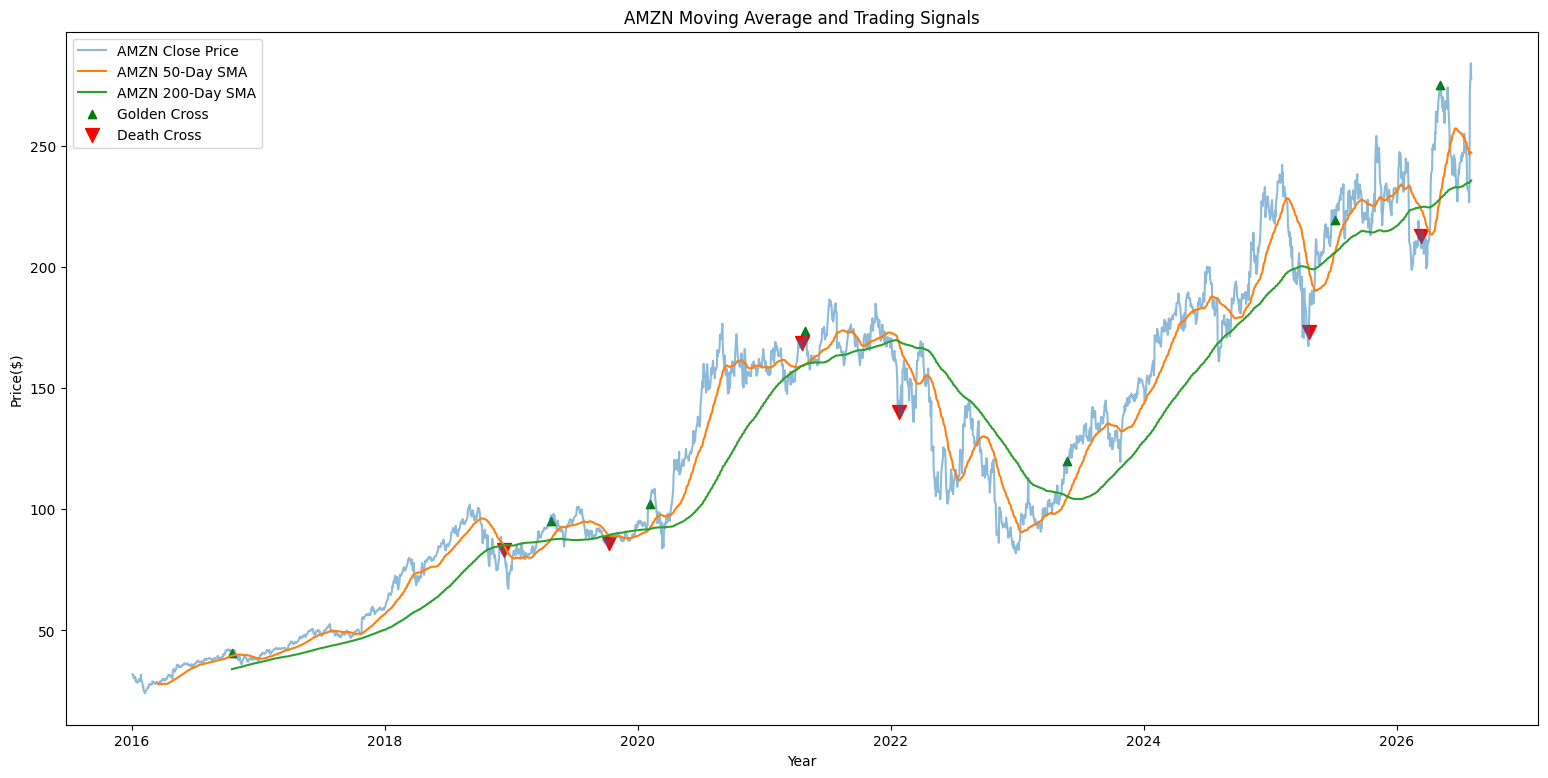

In [3]:


# Identify columns that are added in this cell and might accumulate
derived_column_level0 = ['Return', 'SMA50', 'SMA200', 'Signal', 'Crossover']

# Get all current top-level column names in data
current_top_levels = data.columns.get_level_values(0).unique()

# Filter for derived columns that exist in the current data
existing_derived_cols_in_data = [col_name for col_name in derived_column_level0 if col_name in current_top_levels]

# If any derived columns exist, drop them from the DataFrame
if existing_derived_cols_in_data:
    # Create a list of tuples for all columns to drop (level 0 and level 1 combined)
    columns_to_drop = [col for col in data.columns if col[0] in existing_derived_cols_in_data]
    data = data.drop(columns=columns_to_drop)
# --- End of fix ---

# Get the list of tickers from the DataFrame's MultiIndex columns
tickers = data.columns.get_level_values(1).unique()

# Calculate returns, SMA50, SMA200 for each ticker
# Create temporary DataFrames with appropriate MultiIndex columns
returns_df = data['Close'].pct_change()
returns_df.columns = pd.MultiIndex.from_product([['Return'], tickers])

sma50_df = data['Close'].rolling(window=50).mean()
sma50_df.columns = pd.MultiIndex.from_product([['SMA50'], tickers])

sma200_df = data['Close'].rolling(window=200).mean()
sma200_df.columns = pd.MultiIndex.from_product([['SMA200'], tickers])

# Concatenate these new columns to the original 'data' DataFrame
data = pd.concat([data, returns_df, sma50_df, sma200_df], axis=1)

# Golden Cross and Death Cross
# Initialize 'Signal' columns for each ticker
signal_init_df = pd.DataFrame(0, index=data.index, columns=pd.MultiIndex.from_product([['Signal'], tickers]))
data = pd.concat([data, signal_init_df], axis=1)

for ticker in tickers:
    data.loc[data.index[50:], ('Signal', ticker)] = \
        np.where(data['SMA50'][ticker].iloc[50:] > data['SMA200'][ticker].iloc[50:], 1, 0)

# Identify the CrossOver Points
crossover_df = data['Signal'].diff()
crossover_df.columns = pd.MultiIndex.from_product([['Crossover'], tickers]) # Ensure consistent column naming
data = pd.concat([data, crossover_df], axis=1)

# Select a specific ticker for plotting to resolve ambiguity with multiple tickers
# You can change 'tickers[0]' to any other ticker in the `tickers` list (e.g., 'TSLA', 'NVDA', 'AMZN')
plot_ticker = tickers[0]

# Calculate golden and death cross dates for the selected ticker
golden_cross_dates = data[(data['Crossover'][plot_ticker] == 1)].index
death_cross_dates = data[(data['Crossover'][plot_ticker] == -1)].index

plt.figure(figsize=(19,9))
plt.plot(data.index, data['Close'][plot_ticker], label=f'{plot_ticker} Close Price', alpha=.5)
plt.plot(data.index, data['SMA50'][plot_ticker], label=f'{plot_ticker} 50-Day SMA')
plt.plot(data.index, data['SMA200'][plot_ticker], label=f'{plot_ticker} 200-Day SMA')

plt.scatter(golden_cross_dates,
data.loc[golden_cross_dates][('Close', plot_ticker)], # Access specific ticker's Close price
  marker='^', color='g', label='Golden Cross')


plt.scatter(death_cross_dates,
data.loc[death_cross_dates][('Close', plot_ticker)], # Access specific ticker's Close price
            marker='v', color='r', s= 100, label='Death Cross') # Changed marker to 'v' for clarity in death cross

plt.title(f'{plot_ticker} Moving Average and Trading Signals') # Updated title
plt.xlabel('Year')
plt.ylabel('Price($)') # Corrected typo 'ylabe' to 'ylabel'
plt.legend()
plt.show()

In [4]:
# Anatomy of an automated trading system

class TradingSystem:
  def __init__(self, symbol):
    self.symbol = symbol
    self.data = None

  def fetch_data(self):
    self.data = yf.download(self.symbol, start='2016-01-01', end='2026-08-05')

  def process_data(self):
    self.data['Return'] = self.data['Close'].pct_change()
    self.data['SMA50'] = self.data['Close'].rolling(window=50).mean()
    self.data['SMA200'] = self.data['Close'].rolling(window=200).mean()

  def generate_signals(self):
    self.data['Signal'] = 0
    # Fix ChainedAssignmentError and SyntaxError: Join the split line
    self.data.loc[self.data.index[50:], 'Signal'] = np.where(self.data['SMA50'][50:] > self.data['SMA200'][50:], 1, -1)

  def backtest(self):
    self.data['StrategyReturn'] = self.data['Signal'].shift(1) * self.data['Return']
    cumulative = (1+self.data['StrategyReturn']).cumprod()
    # Fix KeyError: Use .iloc[-1] to access the last element by position
    print('Final portfolio Value:', cumulative.iloc[-1])

system = TradingSystem('TSLA')
system.fetch_data()
system.process_data()
system.generate_signals()
system.backtest()

/tmp/ipykernel_2933/1857755059.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.symbol, start='2016-01-01', end='2026-08-05')
[*********************100%***********************]  1 of 1 completed

Final portfolio Value: 0.5019747702734482


In [5]:
!pip install TA_lib
import talib

# A strategy is a repeatable set of rules or logic designed to generate buy or sell signals.

!pip install TA-Lib

tickers = data.columns.get_level_values(1).unique()

# Example of a Simple Mean-Reversion Rule
window = 20
for ticker in tickers:
    data[('MA', ticker)] = data['Close'][ticker].rolling(window=window).mean()
    data[('Threshold', ticker)] = data[('MA', ticker)] * .98
    data[('Signal_MeanReversion', ticker)] = np.where(data['Close'][ticker] < data[('Threshold', ticker)], 1, 0)

# Example of RSI (Relative Strength Index) signal
# RSI is a classic indicator for overbought/oversold signals

for ticker in tickers:
    data[('RSI', ticker)] = talib.RSI(data['Close'][ticker], timeperiod=14)
    # Corrected the syntax for np.where and added a new signal column name
    data[('Signal_RSI', ticker)] = np.where(data[('RSI', ticker)] < 30, 1, np.where(data[('RSI', ticker)] > 70, -1, 0))


# Performance Calculation

strategy_returns = data['Signal'].shift(1) * data['Return']
cumulative_returns = (1 + strategy_returns).cumprod()
total_return = cumulative_returns.iloc[-1] - 1
annualized_return = cumulative_returns.iloc[-1]**(252/len(data)) - 1 # Approximate

for ticker in tickers:
    print('')
    print(f'Total Return for {ticker}: {total_return[ticker]*100:.2f}%')
    print('')
    print(f"Annualized return for {ticker}: {annualized_return[ticker]*100:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00

Total Return for AMZN: 247.90%

Annualized return for AMZN: 12.53%

Total Return for MSFT: 625.17%

Annualized return for MSFT: 20.64%

Total Return for NVDA: 12657.05%

Annualized return for NVDA: 58.28%

Total Return for TSLA: 552.03%

Annualized return for TSLA: 19.43%


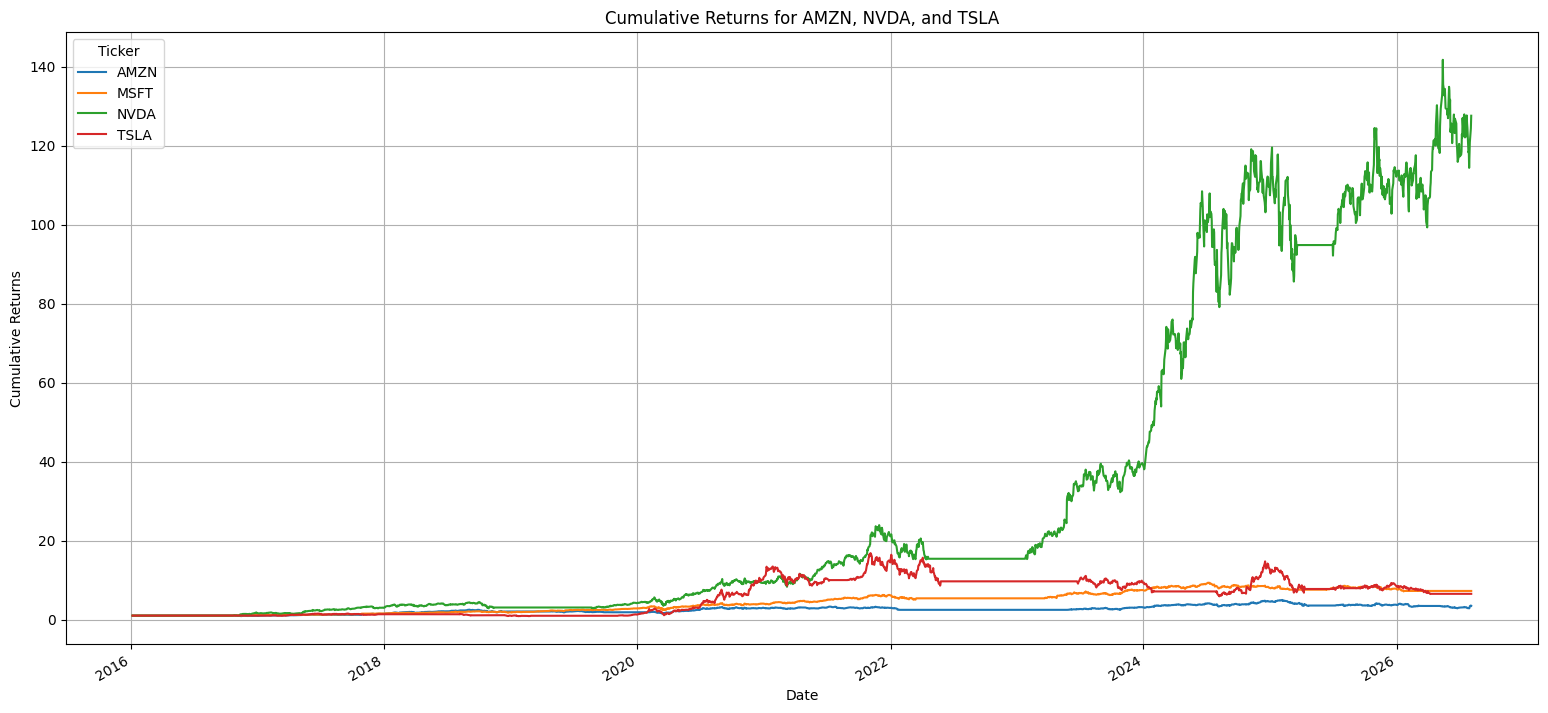

In [6]:
plt.figure(figsize=(19, 9))
cumulative_returns.plot(ax=plt.gca())
plt.title('Cumulative Returns for AMZN, NVDA, and TSLA')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True)
plt.legend(title='Ticker')
plt.show()

In [7]:
#Logging and Error Handling

import logging
logging.basicConfig(filename='trading.log', level=logging.INFO)

try:
  # Use a valid ticker (e.g., 'TSLA') and a different variable name to avoid
  # overwriting the main 'data' DataFrame used by other cells.
  error_handling_data = yf.download('TSLA', start='2016-01-01', end='2026-08-05')

  logging.info('Download data successfully')
except Exception as e:
  logging.error(f'Error fetching data:{str(e)}')


/tmp/ipykernel_2933/1715208346.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  error_handling_data = yf.download('TSLA', start='2016-01-01', end='2026-08-05')
[*********************100%***********************]  1 of 1 completed


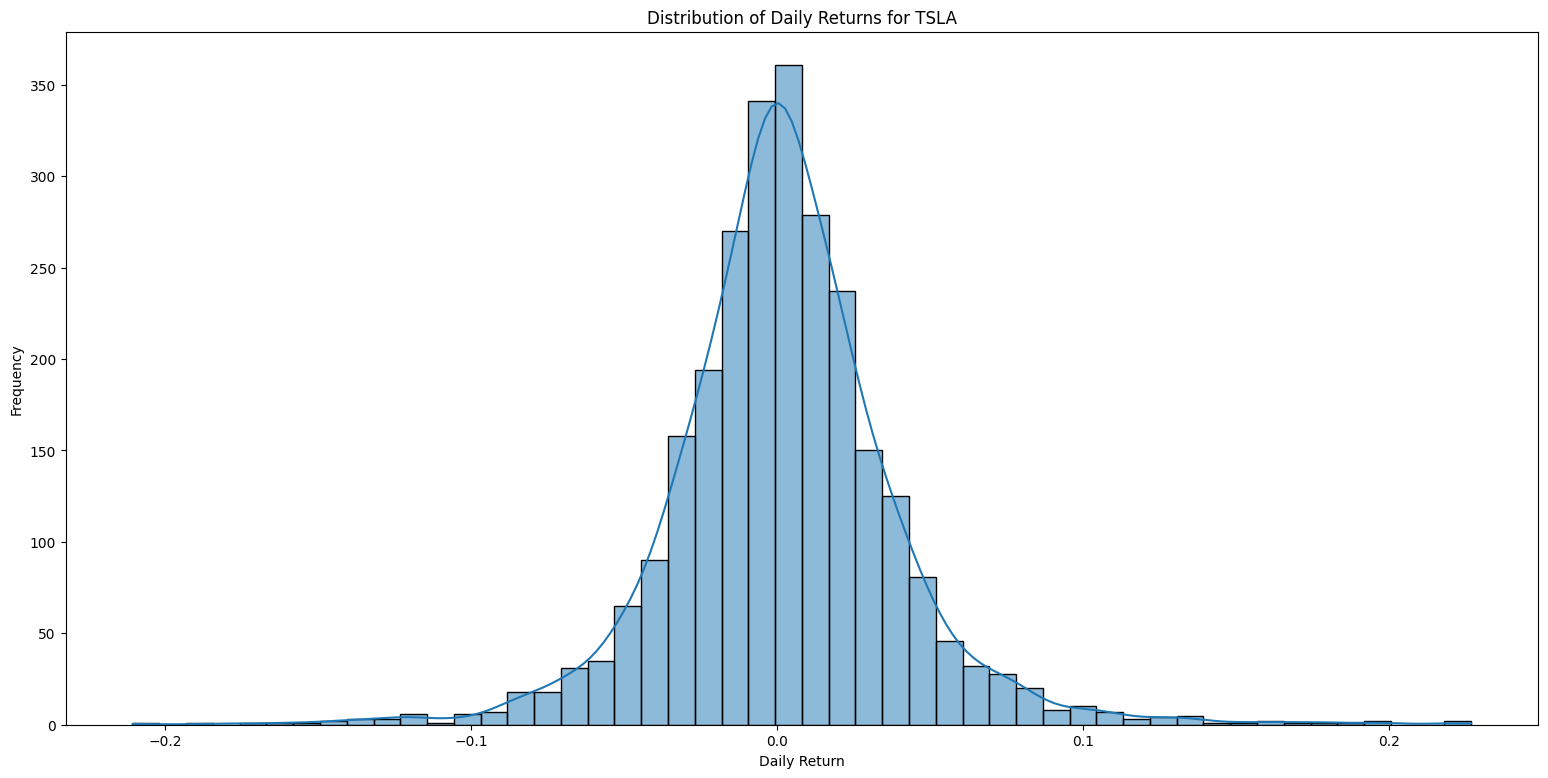

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the returns dataframe created in the previous cell for TSLA
target_ticker = 'TSLA'
plt.figure(figsize=(19,9))
sns.histplot(returns_df[('Return', target_ticker)].dropna(), bins=50, kde=True)
plt.title(f'Distribution of Daily Returns for {target_ticker}')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

# Exercise: Manual Coding Practice

**Goal:** Calculate the 20-day rolling volatility (standard deviation) of TSLA's daily returns and plot it.

**Why?** Volatility tells us how much the price 'swings'. High volatility often means higher risk.

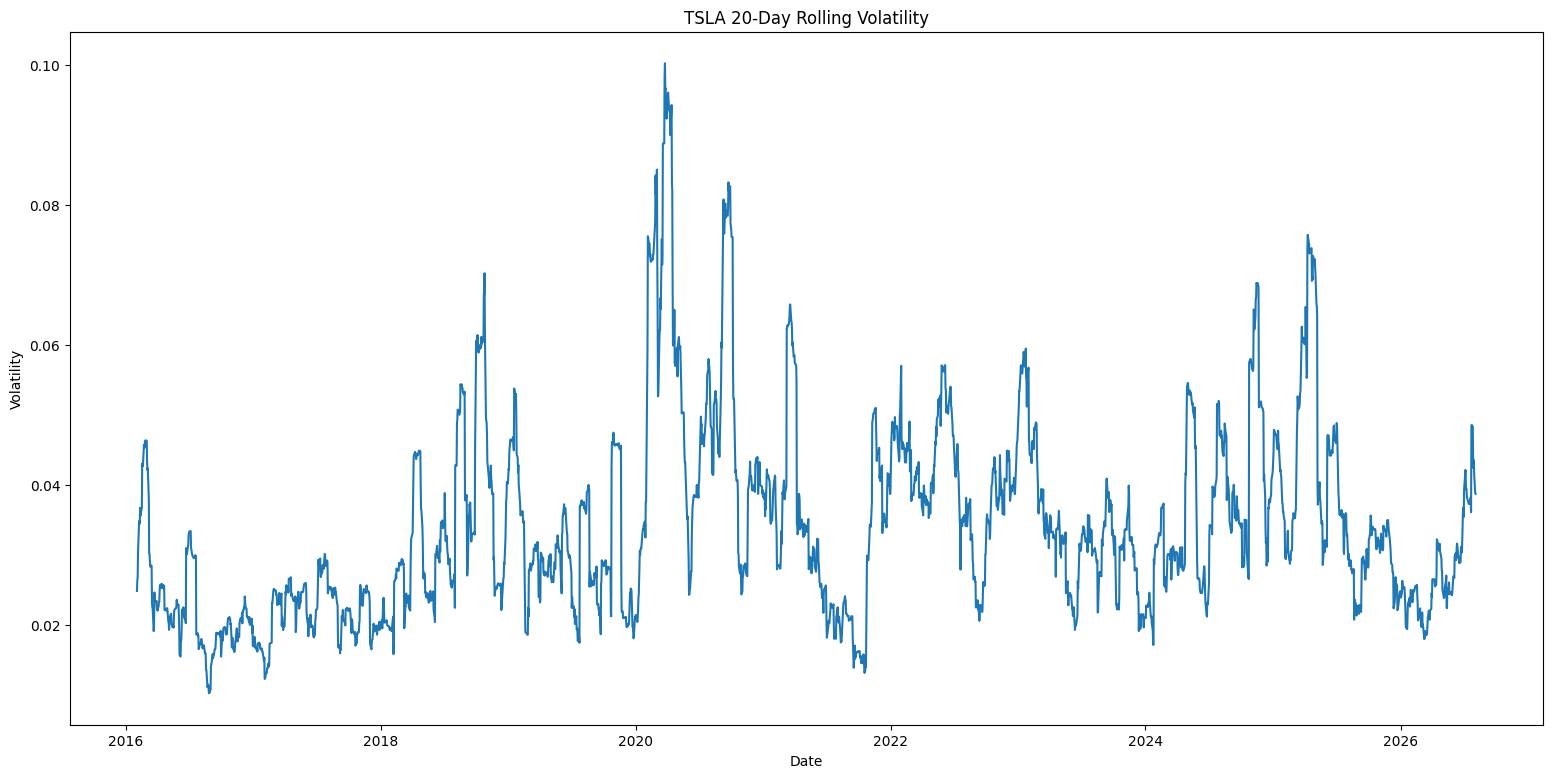

In [9]:
# 1. Use the 'returns_df' variable we created earlier for 'TSLA'
tsla_rets = returns_df[('Return', 'TSLA')]

# 2. Calculate the 20-day rolling standard deviation
# Note the () at the end of .std() to execute the function
rolling_std = tsla_rets.rolling(window=20).std()

# 3. Plot the result
# We set the figure size BEFORE plotting
plt.figure(figsize=(19,9))
plt.plot(rolling_std)

# 4. Add a title and labels
plt.title('TSLA 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

### Exercise 2: The Volatility Filter

**Goal:** Create a signal that says 'Trade' (1) when volatility is low, and 'Wait' (0) when volatility is high.

**Logic:**
1. Find the `mean` (average) of your `rolling_std` series.
2. Create a new column `Filter` where the value is `1` if the current volatility is **less than** the average, and `0` if it is **greater**.
3. Plot the 'Close' price of TSLA, but color the background or add markers where the filter is active.

Average Volatility: 0.03412699997086408


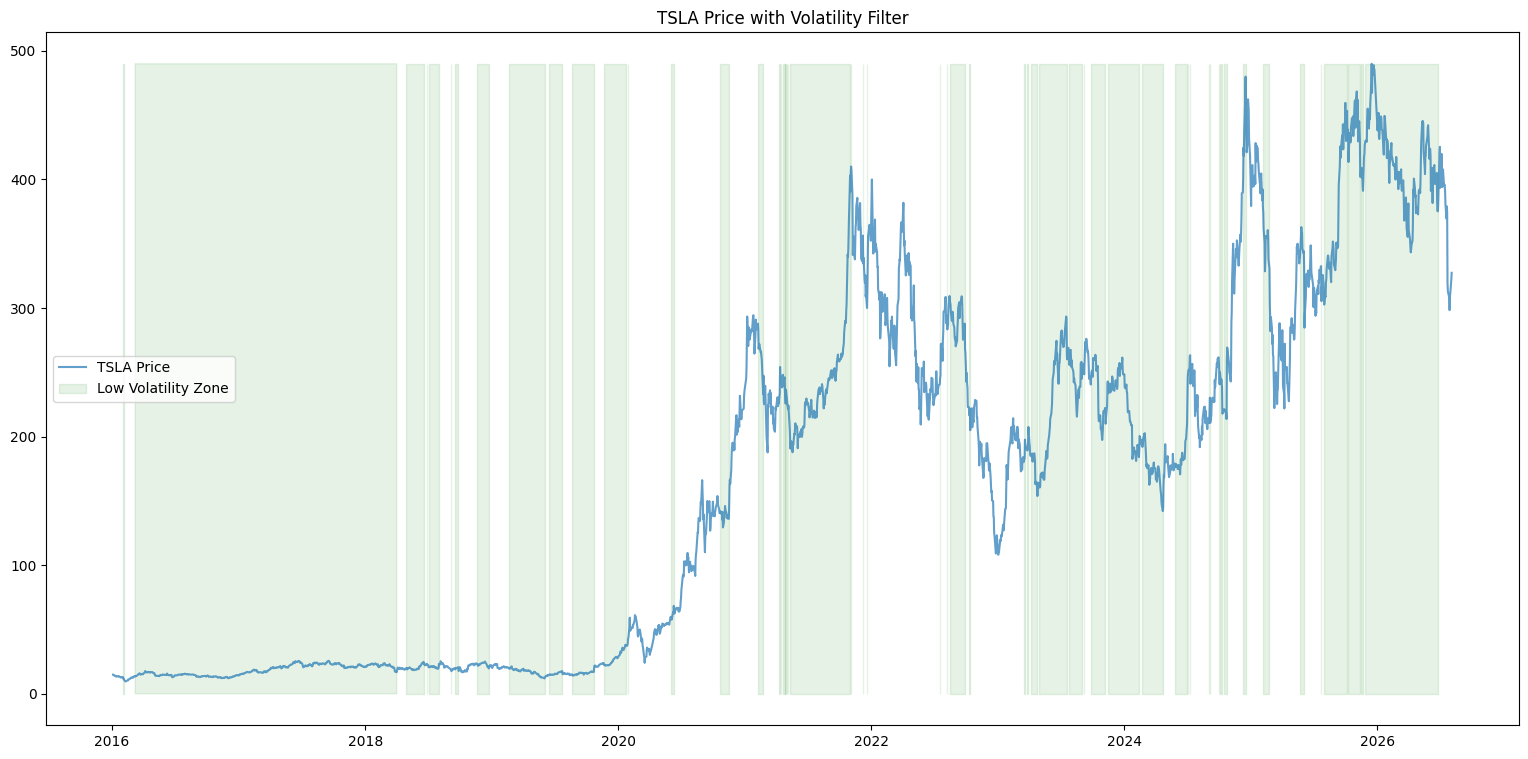

In [10]:
rolling_std = tsla_rets.rolling(window=20).std()
avg_vol = rolling_std.mean()
print(f'Average Volatility: {avg_vol}')

filter_signal = np.where(rolling_std < avg_vol, 1, 0)


plt.figure(figsize=(19,9))
plt.plot(data.index, data['Close']['TSLA'], label='TSLA Price', alpha=0.7)

# 4. Use plt.fill_between to highlight 'Trade' zones
# Fix: Use single '=' for assignment and specify a single color string
plt.fill_between(data.index, 0, data['Close']['TSLA'].max(), where=(filter_signal == 1), color='g', alpha=0.1, label='Low Volatility Zone')

plt.legend()
plt.title('TSLA Price with Volatility Filter')
plt.show()

/tmp/ipykernel_2933/2175342053.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start='2016-01-01', end='2026-08-05')['Close']
[*********************100%***********************]  3 of 3 completed


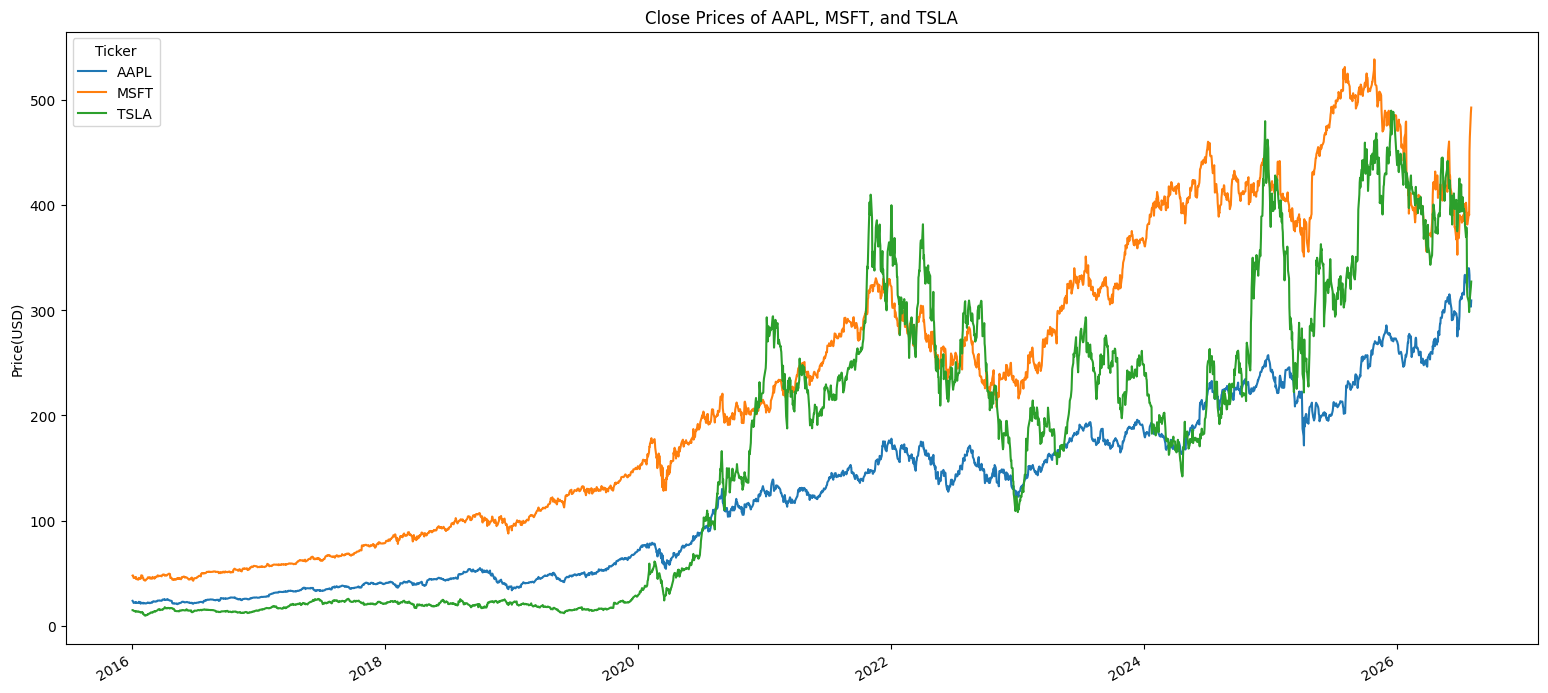

In [11]:
symbols = ['AAPL', 'MSFT', 'TSLA']
data = yf.download(symbols, start='2016-01-01', end='2026-08-05')['Close']
data.to_csv('data/multistock.csv')

data.plot(figsize=(19,9), title='Close Prices of AAPL, MSFT, and TSLA')
plt.ylabel('Price(USD)')
plt.xlabel('')
plt.show()

In [12]:
!pip install ta

class DataHandler:
  def __init__(self, symbol, start_date, end_date):
    self.symbol = symbol
    self.start_date = start_date
    self.end_date = end_date
    self.data = None

  def fetch_data(self):
    self.data = yf.download(self.symbol, start=self.start_date, end=self.end_date)

  def get_latest_data(self, n=1):
    if self.data is not None:
      return self.data.tail(n)
    else:
      raise ValueError('No data available; call fetch_data()first')


class Strategy:
  def __init__(self, data_handler):
    self.data_handler = data_handler
    self.signals = pd.DataFrame()

  def generate_signals(self):
    data = self.data_handler.data.copy()
    symbol = self.data_handler.symbol

    data[('SMA50', symbol)] = data[('Close', symbol)].rolling(window=50).mean()
    data[('SMA200', symbol)] = data[('Close', symbol)].rolling(window=200).mean()

    data[('Signal', symbol)] = 0
    data.loc[data.index[50:], ('Signal', symbol)] = np.where(
        data.loc[data.index[50:], ('SMA50', symbol)] > data.loc[data.index[50:], ('SMA200', symbol)], 1, -1)

    self.signals = data[[('Signal', symbol)]]
    return self.signals



class Portfolio:
  def __init__(self, initial_cash, data_handler, signals):
    self.cash = initial_cash
    self.data_handler = data_handler
    self.signals = signals
    self.positions = 0
    self.position_history = []
    self.portfolio_values = []

  def update_positions(self):
    data = self.data_handler.data
    signals = self.signals

    symbol = self.data_handler.symbol
    signal_series = signals[('Signal', symbol)]

    for date, signal in signal_series.items():
      if date in data.index:
        price_data = data.loc[date]
        price = price_data[('Close', symbol)]

        if signal == 1 and self.positions == 0: # Buy condition
          self.positions = 1
          self.cash -= price
          self.position_history.append((date, 'BUY', price))
        elif signal == -1 and self.positions == 1: # Sell condition for a negative signal
          self.positions = 0
          self.cash += price
          self.position_history.append((date, 'SELL', price))

        current_position_value = self.positions * price
        current_val = self.cash + current_position_value
        self.portfolio_values.append((date, current_val))
      else:
        # Handle cases where the date from signals might not be in data (e.g., due to rolling window)
        # For simplicity, we'll just skip this date for now or add a dummy value
        current_val = self.cash + self.positions * (
            data[('Close', symbol)].iloc[-1] if not data.empty else 0
        ) # Use last available price if date not found
        self.portfolio_values.append((date, current_val))

  def print_performance(self):
    if not self.position_history:
      print("No trading activity.")
    else:
      for event in self.position_history:
        print(f'{event[0]}: {event[1]} at $ {event[2]:.2f}')

    if not self.portfolio_values:
      print("No portfolio value history.")
    else:
      print(f'Final Portfolio val: $ {self.portfolio_values[-1][1]:.2f}')




class ExecutionHandler:
  def __init__(self):
    self.orders = []

  def execute_order(self, symbol, quantity, order_type='market'):
    print(f'Executing order: {order_type},{quantity} shares of {symbol}')
    self.orders.append({'symbol':symbol,'quantity':quantity,'order_type':order_type})




class TradingSystem:
  def __init__(self, symbol, start_date, end_date, initial_cash):
     self.data_handler = DataHandler(symbol, start_date, end_date)
     self.strategy = None
     self.portfolio = None
     self.execution_handler = ExecutionHandler()
     self.initial_cash = initial_cash

  def run(self):
    self.data_handler.fetch_data()
    self.strategy = Strategy(self.data_handler)
    signals = self.strategy.generate_signals()
    self.portfolio = Portfolio(self.initial_cash, self.data_handler, signals)


    self.portfolio.update_positions()
    self.portfolio.print_performance()

# Adding indicators

from ta.trend import MACD
from ta.momentum import RSIIndicator




class AdvancedStrategy(Strategy):
  def generate_signals(self):
    data = self.data_handler.data.copy()
    data['SMA50'] = data['Close'].rolling(window=500).mean()
    data['SMA200'] = data['Close'].rolling(window=200).mean()

    macd = MACD(data['Close'])
    rsi = RSIIndicator(data['Close'])

    data['MACD'] = macd.macd_diff()
    data['RSI'] = rsi.rsi

    data['Signal'] = 0
    data.loc[(data['SMA50'] > data['SMA200']) & (data['MACD'] > 0) & (data['RSI'] < 70), 'Signal'] = 1
    data.loc[(data['SMA50'] < data['SMA50']) | (data['MACD'] < 0) | (data['RSI'] >70), 'Signal'] = -1

    self.signals = data[['Signal']]
    return self.signals

  #  Risk Management
#   Implementing Position Limits



class RiskManagementPortfolio(Portfolio):

  def __init__(self, initial_cash, data_handler, signals, max_position_pct=.1):
    super().__init__(initial_cash, data_handler, signals)

    self.max_position_pct = max_position_pct # Max % portfolio per trade

  def update_positions(self):
    data = self.data_handler.data
    signals = self.signals
    portfolio_value = self.cash + self.positions*data['Close'].iloc[0]

    for date, signal in signals['Signal'].iteritems():
      price = data.loc[date]['Close']

      max_position_size = portfolio_value* self.max_position_pct
      max_shares = int(max_position_size / price)

      if signal == 1 and self.positions < max_shares:
        shares_to_buy = max_shares - self.positions

        cost = shares_to_buy * price

        if self.chash >= cost:

          self.positions += shares_to_buy
          self.cash -= cost
          self.position_history.append((date, 'BUY', shares_to_buy, price))

        elif signal == -1 and self.positions > 0 :
          self.cash += self.positions * price
          self.positions_history.append((date, 'SELL', self.positions, price))

          self.positions = 0
          current_value = self.cash + self.positions *price

          self.portfolio_value.append((date, current_value))

  #  logging and monitoring lobustness

import logging
logging.basicConfig(filename='trading.log', level=logging.INFO, format='%(asctime)s:%(message)')

class LoggingExecutionHandler(ExecutionHandler):

  def execute_order(self, symbol, quantity, order_type='market'):
    super().execute_order(symbol, quantity, order_type)
    logging_info(f'Executed{order_type} order for {quantity} shares of {symbol}')

#  Unit testing individual modules
# Example test of data handler

def test_data_handler():
  dh = DataHandler('AAPL', '2026-04-01', '2026-04-28')

  dh.fetch_data()
  assert dh.data is not None
  assert not dh.data.empty
  print('DataHandler test passed.')
test_data_handler()

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=f69254eaa5d4eba2fb659743e4cd7fad89eb254288b1066244d3b57137b55412
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


/tmp/ipykernel_2933/707586070.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(self.symbol, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed

DataHandler test passed.


In [13]:
from IPython.utils.io import raw_print_err
data = pd.read_csv('data/tickers_daily.csv', index_col=0, parse_dates=True, header=[0,1])

# Get the list of tickers for creating MultiIndex columns
tickers = data.columns.get_level_values(1).unique()

# Calculate Returns for each ticker
returns_df = data['Close'].pct_change()
returns_df.columns = pd.MultiIndex.from_product([['Return'], tickers])

# Calculate SMA20 for each ticker
sma20_df = data['Close'].rolling(window=20).mean()
sma20_df.columns = pd.MultiIndex.from_product([['SMA20'], tickers])

# Concatenate results
data = pd.concat([data, returns_df, sma20_df], axis=1)

# Generate 'Signal'
signal_values = np.where(data['Close'] > data['SMA20'], 1, -1)
signal_df = pd.DataFrame(signal_values, index=data.index, columns=pd.MultiIndex.from_product([['Signal'], tickers]))
data = pd.concat([data, signal_df], axis=1)

data.dropna(inplace=True)

# Fixed shift syntax and naming typo
data_strat_ret = data['Signal'].shift(1) * data['Return']
data_strat_ret.columns = pd.MultiIndex.from_product([['Strategy_Return'], tickers])

data_cum_ret = (1 + data_strat_ret.fillna(0)).cumprod()
data_cum_ret.columns = pd.MultiIndex.from_product([['Cumulative_Strategy_Returns'], tickers])

data = pd.concat([data, data_strat_ret, data_cum_ret], axis=1)

print(data.head())

                Close                                       High             \
Ticker           AMZN       MSFT      NVDA       TSLA       AMZN       MSFT   
Date                                                                          
2016-02-01  28.740499  47.692253  0.713832  13.129333  29.090000  48.023511   
2016-02-02  27.605000  46.201607  0.683622  12.185333  28.577999  47.299983   
2016-02-03  26.553499  45.469364  0.687033  11.565333  27.799999  46.541590   
2016-02-04  26.813000  45.329884  0.687276  11.688667  26.949499  46.035985   
2016-02-05  25.106501  43.725906  0.643911  10.840000  26.472500  45.329887   

                                       Low             ... Signal       \
Ticker          NVDA       TSLA       AMZN       MSFT  ...   NVDA TSLA   
Date                                                   ...               
2016-02-01  0.717486  13.301333  28.515499  47.509191  ...      1   -1   
2016-02-02  0.710177  12.874667  27.504499  45.896503  ...     -1   -1 

Total Return (TSLA): 385.61%
Annualized Return (TSLA): 16.27%
Annualized Volatility (TSLA): 58.85%
Sharpe Ratio (TSLA): 0.52
Max Drawdown (TSLA): -88.10%


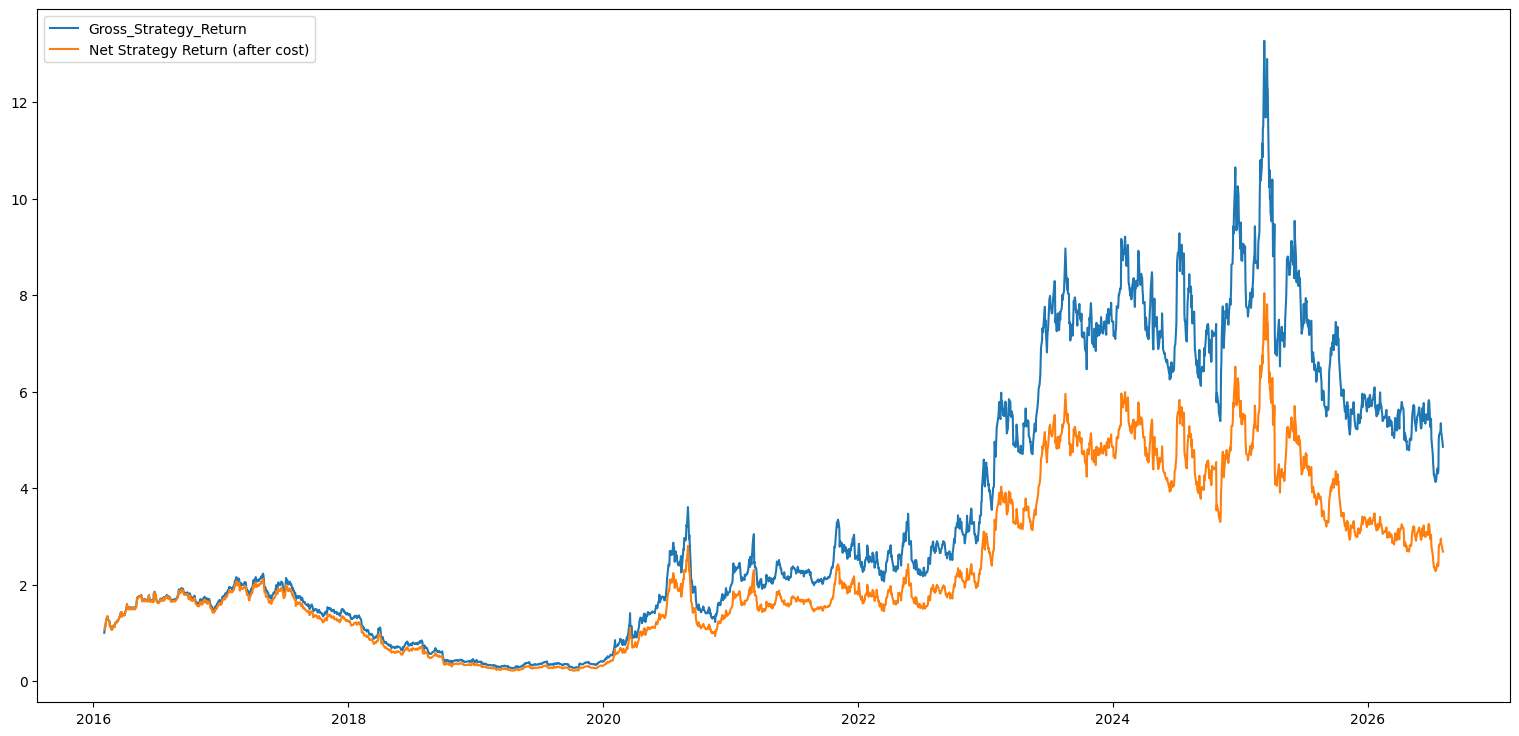

In [14]:
# Select a ticker to calculate metrics for
ticker = 'TSLA'

# Total Return
# Accessing the corrected column name
total_return = data[('Cumulative_Strategy_Returns', ticker)].iloc[-1] - 1
print(f'Total Return ({ticker}): {total_return*100:.2f}%')

# Annualized Return
days = len(data)
annualized_return = (data[('Cumulative_Strategy_Returns', ticker)].iloc[-1])**(252/days) - 1
print(f'Annualized Return ({ticker}): {annualized_return*100:.2f}%')

# Annualized Volatility
annualized_volatility = data[('Strategy_Return', ticker)].std() * np.sqrt(252)
print(f'Annualized Volatility ({ticker}): {annualized_volatility*100:.2f}%')

# Sharpe Ratio
risk_free_rate = 0.02
excess_return = data[('Strategy_Return', ticker)] - risk_free_rate/252
sharpe_ratio = (excess_return.mean() / excess_return.std()) * np.sqrt(252)
print(f'Sharpe Ratio ({ticker}): {sharpe_ratio:.2f}')

# Max Drawdown
cumulative = data[('Cumulative_Strategy_Returns', ticker)]
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(f'Max Drawdown ({ticker}): {max_drawdown*100:.2f}%')

#  Win Rate and Trade Statistics

def calculate_win_rate(returns, signals):
  trades = []
  positions = []
  entry_price = []

  for i in range(1, len(signals)):
    if signals[i-1] == 0:
      continue

    # Initialize 'position' for each call
    position = None

    if position is None and signals[i-1] == 1:
      position = 'long'
      entry_price = returns.index[i]
    elif position == 'long' and signals[i-1] == -1:
      exit_price = returns.index[i]
      trades.append(exit_price - entry_price)
      position = None


    win_rate = sum([ 1 for t in trades if t > 0])/ len(trades) if trades else 0
    return win_rate

    print(f'Win Rate: {calculate_win_rate(data['Return'], data['Signal'])*100:.2f}%')

# Handling transaction costs and slippage
#  Incorporarte a fixed cost per trade and reduce strategy returns accordingly

commissions_per_trade = .001

# Get all unique tickers from the data's columns (level 1)
all_tickers = data.columns.get_level_values(1).unique()

# Calculate 'Trades' for all tickers and create MultiIndex columns
trades_calculated = data['Signal'].diff().fillna(0).abs()
trades_calculated.columns = pd.MultiIndex.from_product([['Trades'], all_tickers])

# Remove existing 'Trades' columns to avoid duplicates if cell is re-run
existing_trades_cols = [col for col in data.columns if col[0] == 'Trades']
if existing_trades_cols:
    data = data.drop(columns=existing_trades_cols, level=0)
# Concatenate the new 'Trades' DataFrame to the main 'data' DataFrame
data = pd.concat([data, trades_calculated], axis=1)

# Calculate 'Strategy_Return_Net' for all tickers and create MultiIndex columns
strategy_return_net_calculated = data['Strategy_Return'] - data['Trades'] * commissions_per_trade
strategy_return_net_calculated.columns = pd.MultiIndex.from_product([['Strategy_Return_Net'], all_tickers])

# Remove existing 'Strategy_Return_Net' columns to avoid duplicates if cell is re-run
existing_strategy_return_net_cols = [col for col in data.columns if col[0] == 'Strategy_Return_Net']
if existing_strategy_return_net_cols:
    data = data.drop(columns=existing_strategy_return_net_cols, level=0)
# Concatenate the new 'Strategy_Return_Net' DataFrame to the main 'data' DataFrame
data = pd.concat([data, strategy_return_net_calculated], axis=1)


# Calculate 'Cumulative_Strategy_Return_Net' for all tickers and create MultiIndex columns
cumulative_strategy_return_net_calculated = (1 + data['Strategy_Return_Net']).cumprod()
cumulative_strategy_return_net_calculated.columns = pd.MultiIndex.from_product([['Cumulative_Strategy_Return_Net'], all_tickers])

# Remove existing 'Cumulative_Strategy_Return_Net' columns to avoid duplicates if cell is re-run
existing_cumulative_strategy_return_net_cols = [col for col in data.columns if col[0] == 'Cumulative_Strategy_Return_Net']
if existing_cumulative_strategy_return_net_cols:
    data = data.drop(columns=existing_cumulative_strategy_return_net_cols, level=0)
# Concatenate the new 'Cumulative_Strategy_Return_Net' DataFrame to the main 'data' DataFrame
data = pd.concat([data, cumulative_strategy_return_net_calculated], axis=1)


plt.figure(figsize=(19,9))
# Plot for the specific 'ticker' (TSLA)
plt.plot(data.index, data[('Cumulative_Strategy_Returns', ticker)], label='Gross_Strategy_Return')
plt.plot(data.index, data[('Cumulative_Strategy_Return_Net', ticker)], label='Net Strategy Return (after cost)')
plt.legend()
plt.show()

In [15]:
#  Logging and monitoring for Robustness

import logging
# Fixed format string (added missing 's' to message) and basic configuration
logging.basicConfig(filename='trading.log', level=logging.INFO, format='%(asctime)s:%(message)s')

# NOTE: Ensure the cell defining 'ExecutionHandler' (3WNcwAPrzh2Z) has been executed first.
try:
    class LoggingExecutionHandler(ExecutionHandler):
      def execute_order(self, symbol, quantity, order_type='market'):
        super().execute_order(symbol, quantity, order_type)
        # Fixed typo: changed logging_info to logging.info
        logging.info(f'Executed {order_type} order for {quantity} shares of {symbol}')

    # Use case
    exec_handler = LoggingExecutionHandler()
    exec_handler.execute_order('tickers', 5)
except NameError as e:
    print(f"Error: {e}. Please run the cell defining ExecutionHandler (cell 3WNcwAPrzh2Z) before running this cell.")

Executing order: market,5 shares of tickers


In [16]:
# Event Driven Backtesting: Simulating real World Order Execution

# For more realism, create classes that simulate order replacement, fills, and portfolio update.

class MarketEvent:
  def __init__(self, data):
    self.data = data

class SignalEvent:
  def __init__(self, symbol, datetime, signal_type):
    self.symbol = symbol
    self.datetime = datetime
    self.signal_type = signal_type   # BUY or SELL

class OrderEvent:
  def __init__(self,symbol, quantity, order_type,direction):
    self.symbol = symbol
    self.quantity = quantity
    self.order_type = order_type      # eg: Market
    self.direction = direction        # BUY or SELL

class FillEvent:
  def __init__(self, symbol, quantity, direction, price, commission):
    self.symbol = symbol
    self.quantity = quantity
    self.direction = direction
    self.price = price
    self.commission = commission

#  Simple Backtest Event Loop skeleton

import queue

class Backtest:
  def __init__(self,symbol,initial_cash):
    self.symbol = symbol
    self.initial_cash = initial_cash
    self.events = queue.Queue()
    # Fixed typo: downloads -> download
    self.data = yf.download(symbol, start='2016-07-01', end='2026-08-05')
    self.signals = queue.Queue()
    self.portfolio = Portfolio(initial_cash)
    self.current_date = None

  def update_market(self):
    #  Simulate new data event
    for date, row in self.data.iterrows():
      self.current_date = date
      event = MarketEvent(row)
      self.events.put(event)
      self.process_events()

  def process_events(self):
    while not self.events.empty():
      event = self.events.get()
      if isinstance(event, MarketEvent):
        signal_event = SignalEvent(self.symbol, self.current_date, 'BUY')
        self.events.put(signal_event)

      elif isinstance(event, SignalEvent):
        order = OrderEvent(event.symbol, 10, 'MARKET', event.signal_type)
        self.events.put(order)

      elif isinstance(event, OrderEvent):
        # Fixed typo: oc -> loc
        price = self.data.loc[self.current_date]['Close']
        fill = FillEvent(event.symbol, event.quantity, event.direction, price, 1.0)
        self.portfolio.update_on_fill(fill)


class Portfolio:
  def __init__(self,initial_cash):
    self.cash = initial_cash
    self.positions = 0
    self.trades = []

  def update_on_fill(self, fill):
    if fill.direction == 'BUY':
      self.cash -= fill.quantity * fill.price + fill.commission
      self.positions += fill.quantity
    else:
      self.cash += fill.quantity * fill.price - fill.commission
      self.positions -= fill.quantity
    self.trades.append(fill)

# Use case
bt = Backtest('AAPL', 1000)
bt.update_market()
print(f"Cash after backtest: {bt.portfolio.cash}")
print(f'Positions after backtest: {bt.portfolio.positions}')

/tmp/ipykernel_2933/3671035654.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.data = yf.download(symbol, start='2016-07-01', end='2026-08-05')
[*********************100%***********************]  1 of 1 completed


Cash after backtest: Ticker
AAPL   -3.254176e+06
Name: 2016-07-01 00:00:00, dtype: float64
Positions after backtest: 25360


/tmp/ipykernel_2933/1478582930.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '513.0706691741943' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.at[data.index[i], ('Cash', selected_ticker)] = cash


Total trades executed: 62
Final Portfolio Value: $2459.47


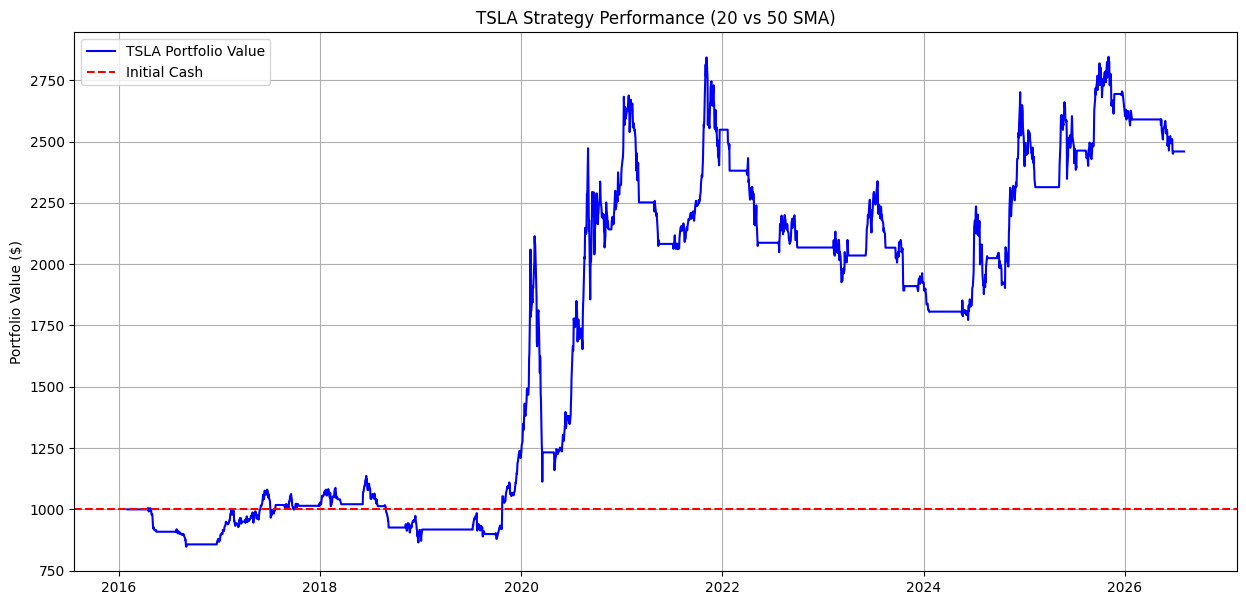

In [17]:
# Ensure signals are calculated for the backtest
selected_ticker = 'TSLA'
initial_cash = 1000
position_size_pct = 0.5 # Increased size to see bigger swings

# 1. Use shorter SMAs so we actually get signals in a 1-year period
sma_short_window = 20
sma_long_window = 50

sma_short = data['Close'][selected_ticker].rolling(window=sma_short_window).mean()
sma_long = data['Close'][selected_ticker].rolling(window=sma_long_window).mean()

# Generate signals: 1 for Buy (Golden Cross), -1 for Sell (Death Cross)
data[('Signal', selected_ticker)] = 0
data.loc[data.index[sma_long_window:], ('Signal', selected_ticker)] = np.where(
    sma_short.iloc[sma_long_window:] > sma_long.iloc[sma_long_window:], 1, -1
)

# 2. Initialize tracking
data[('Cash', selected_ticker)] = initial_cash
data[('Positions', selected_ticker)] = 0
cash = initial_cash
trades_count = 0

# 3. Backtest Loop
for i in range(1, len(data)):
    price = data['Close'][selected_ticker].iloc[i]
    prev_positions = data['Positions'][selected_ticker].iloc[i-1]
    # We look at the signal from the previous day to avoid look-ahead bias
    signal = data['Signal'][selected_ticker].iloc[i-1]

    if signal == 1 and prev_positions == 0:
        # Buy
        max_shares = int((cash * position_size_pct) / price)
        if max_shares > 0:
            cash -= max_shares * price
            data.at[data.index[i], ('Positions', selected_ticker)] = max_shares
            trades_count += 1
    elif signal == -1 and prev_positions > 0:
        # Sell
        cash += prev_positions * price
        data.at[data.index[i], ('Positions', selected_ticker)] = 0
        trades_count += 1
    else:
        # Keep current position
        data.at[data.index[i], ('Positions', selected_ticker)] = prev_positions

    data.at[data.index[i], ('Cash', selected_ticker)] = cash

# 4. Calculate Portfolio Value
data[('Portfolio_Value', selected_ticker)] = (data['Positions'][selected_ticker] * data['Close'][selected_ticker]) + data['Cash'][selected_ticker]

print(f"Total trades executed: {trades_count}")
print(f"Final Portfolio Value: ${data[('Portfolio_Value', selected_ticker)].iloc[-1]:.2f}")

plt.figure(figsize=(15,7))
plt.plot(data[('Portfolio_Value', selected_ticker)], label=f'{selected_ticker} Portfolio Value', color='blue')
plt.axhline(y=initial_cash, color='red', linestyle='--', label='Initial Cash')
plt.title(f'{selected_ticker} Strategy Performance ({sma_short_window} vs {sma_long_window} SMA)')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2933/3693053378.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2016-01-01', end='2026-08-05')['Close']
[*********************100%***********************]  4 of 4 completed


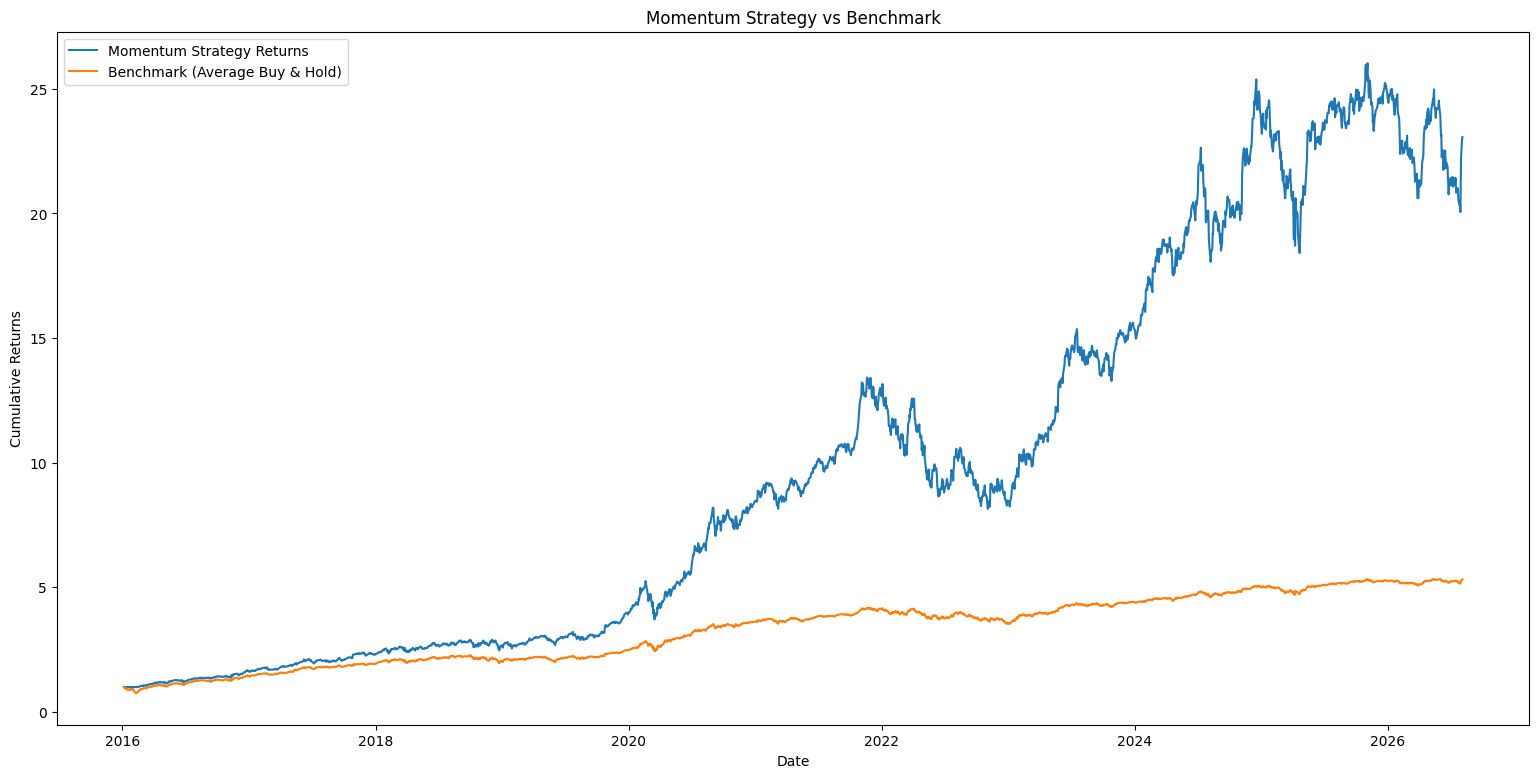

Final Positions:
Ticker      AMZN  MSFT  NVDA  TSLA
Date                              
2026-07-29     1     1     1     0
2026-07-30     1     1     1     0
2026-07-31     1     1     1     0
2026-08-03     1     1     1     0
2026-08-04     1     1     1     0


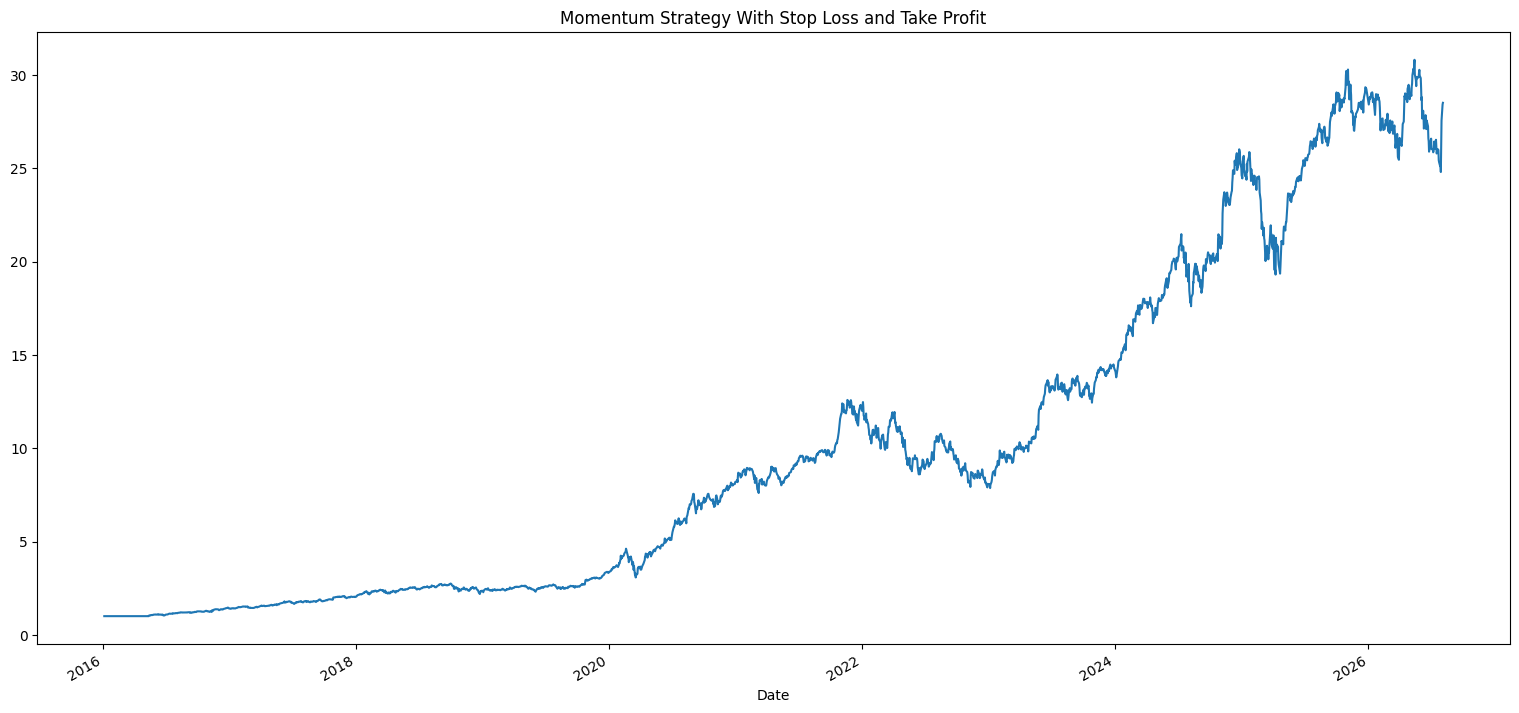

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["TSLA" ,"NVDA", "AMZN",'MSFT']

# Momentum Trading Strategy
data = yf.download(tickers, start='2016-01-01', end='2026-08-05')['Close']
lookback = 90
momentum = data.pct_change(periods=lookback)
lookback = 30
momentum = data.pct_change(periods=lookback)
momentum_rank = momentum.rank(axis=1, ascending=False)

top_n = 3
positions = (momentum_rank <= top_n).astype(int)

daily_returns =data.pct_change()
shifted_positions = positions.shift()
strategy_returns = (shifted_positions * daily_returns).mean(axis=1)
cumulative_returns = (1 + strategy_returns).cumprod()

# Visualizing Momentum Strategy Performance
benchmark_returns = daily_returns.cumsum().apply(lambda x: (1+x))

plt.figure(figsize=(19,9))
plt.plot(cumulative_returns, label='Momentum Strategy Returns')
plt.plot(benchmark_returns.mean(axis=1), label='Benchmark (Average Buy & Hold)')
plt.title('Momentum Strategy vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Position sizing and portfolio allocation
weights = momentum.div(momentum.sum(axis=1), axis=0)
weights = weights.where(weights > 0, 0)
weights = weights.div(weights.sum(axis=1), axis=0)

strategy_returns_weighted = (weights.shift() * daily_returns).sum(axis=1)
cumulative_returns_weighted = (1 + strategy_returns_weighted).cumprod()

# Stop loss and take profit
stop_loss_pct = 0.1
take_profit_pct = 0.2
entry_prices = data.where(positions.shift() == 1)
returns_since_entry = (data - entry_prices) / entry_prices
exit_signals = (returns_since_entry <= -stop_loss_pct) | (returns_since_entry >= take_profit_pct)
positions = positions.mask(exit_signals, 0)

print("Final Positions:")
print(positions.tail())

# Backtesting Function
def momentum_backtest(df_close, lookback=90, top_n=3, stop_loss_pct=None, take_profit_pct=None):
    mom = df_close.pct_change(periods=lookback)
    rank = mom.rank(axis=1, ascending=False)
    pos = (rank <= top_n).astype(int)

    if stop_loss_pct is not None or take_profit_pct is not None:
        entry = df_close.where(pos.shift() == 1)
        ret_entry = (df_close - entry) / entry.replace(0, np.nan)
        exits = pd.DataFrame(False, index=df_close.index, columns=df_close.columns)
        if stop_loss_pct is not None:
            exits = exits | (ret_entry <= -stop_loss_pct)
        if take_profit_pct is not None:
            exits = exits | (ret_entry >= take_profit_pct)
        pos = pos.mask(exits, 0)

    d_ret = df_close.pct_change()
    s_ret = (pos.shift() * d_ret).mean(axis=1)
    return (1 + s_ret).cumprod()

cum_returns_with_stops = momentum_backtest(data, lookback=90, top_n=3, stop_loss_pct=stop_loss_pct, take_profit_pct=take_profit_pct)
cum_returns_with_stops.plot(figsize=(19,9), title='Momentum Strategy With Stop Loss and Take Profit')
plt.show()

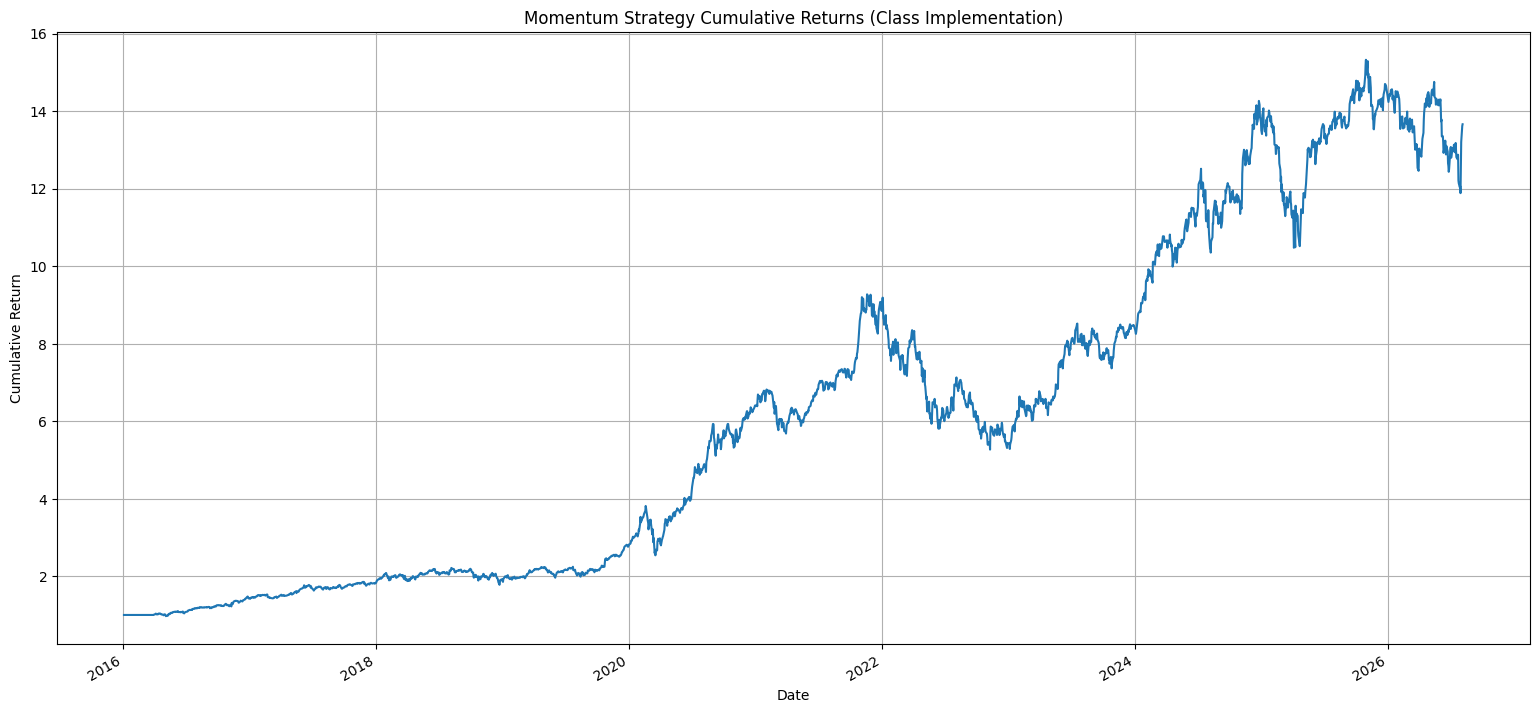

In [19]:
# Momentum Strategy Cumulative Returns

class MomentumStrategy:
  def __init__(self, data, lookback=90, top_n=3, stop_loss=None, take_profit=None, commission=.001):
    self.data = data
    self.lookback = lookback
    self.top_n = top_n
    self.stop_loss = stop_loss
    self.take_profit = take_profit
    self.commission = commission
    self.positions = None
    self.strategy_returns = None

  def generate_positions(self):
    # Calculate momentum based on percentage change
    momentum = self.data.pct_change(periods=self.lookback)
    momentum_rank = momentum.rank(axis=1, ascending=False)
    positions = (momentum_rank <= self.top_n).astype(int)

    if self.stop_loss is not None or self.take_profit is not None:
      entry_prices = self.data.where(positions.shift() == 1)
      returns_since_entry = (self.data - entry_prices) / entry_prices.replace(0, np.nan)
      exit_signals = pd.DataFrame(False, index=self.data.index, columns=self.data.columns)

      if self.stop_loss is not None:
        exit_signals = exit_signals | (returns_since_entry <= -self.stop_loss)
      if self.take_profit is not None:
        exit_signals = exit_signals | (returns_since_entry >= self.take_profit)

      positions = positions.mask(exit_signals, 0)

    self.positions = positions
    return positions

  def backtest(self):
    daily_returns = self.data.pct_change()
    positions_shift = self.positions.shift()
    # Estimate trading activity for commissions
    trades = positions_shift.diff().abs().fillna(0)
    daily_commission = (trades.sum(axis=1) * self.commission)

    strategy_returns = (positions_shift * daily_returns).mean(axis=1)
    strategy_returns_net = strategy_returns - daily_commission
    self.strategy_returns = strategy_returns_net
    return (1 + strategy_returns_net).cumprod()

# Use case
momentum_strat = MomentumStrategy(data, 60, 3, .1, .2)
momentum_strat.generate_positions()
cum_returns = momentum_strat.backtest()

plt.figure(figsize=(19,9))
cum_returns.plot(title='Momentum Strategy Cumulative Returns (Class Implementation)')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

/tmp/ipykernel_2933/3690356520.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2016-01-01')['Close']
[*********************100%***********************]  4 of 4 completed


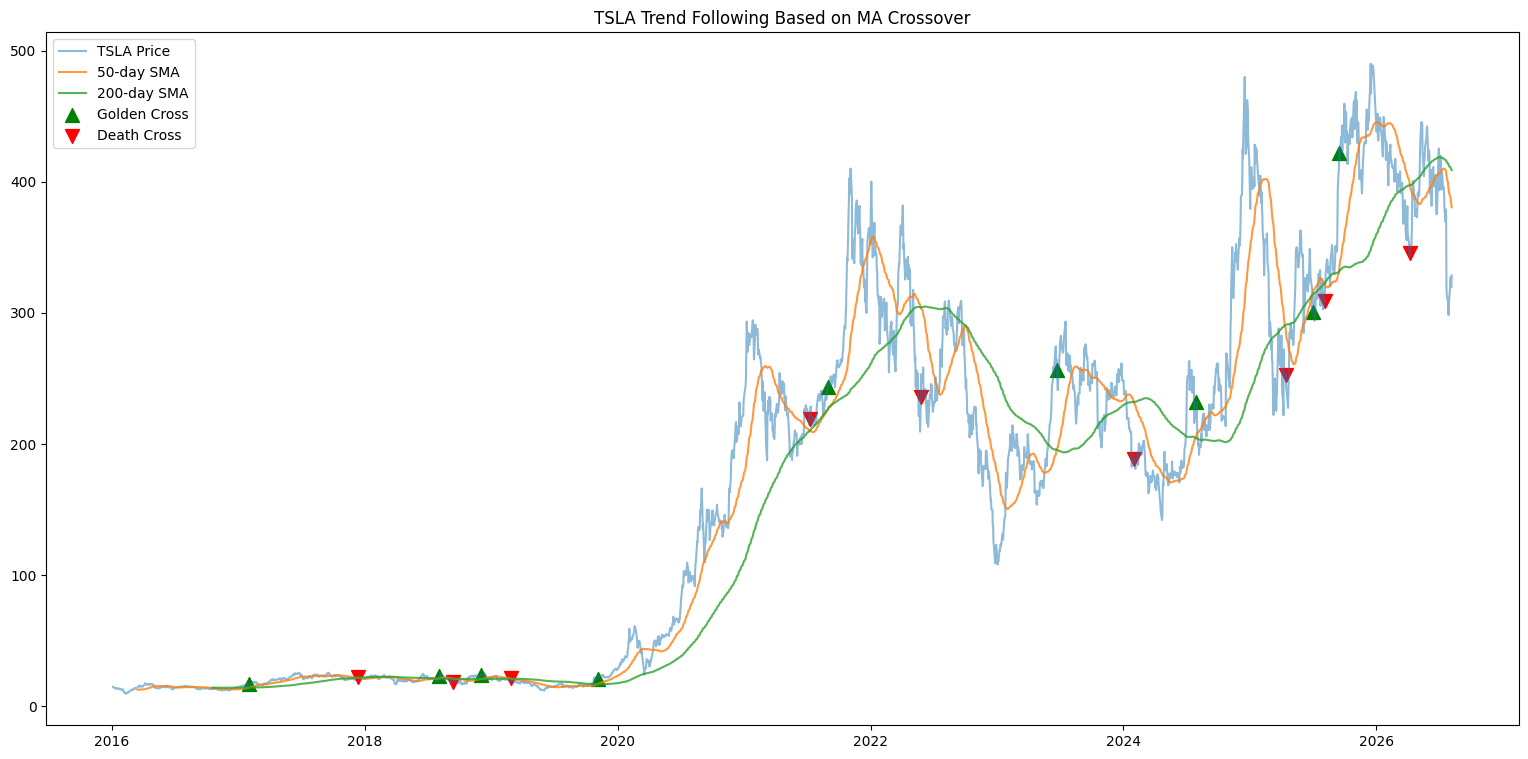

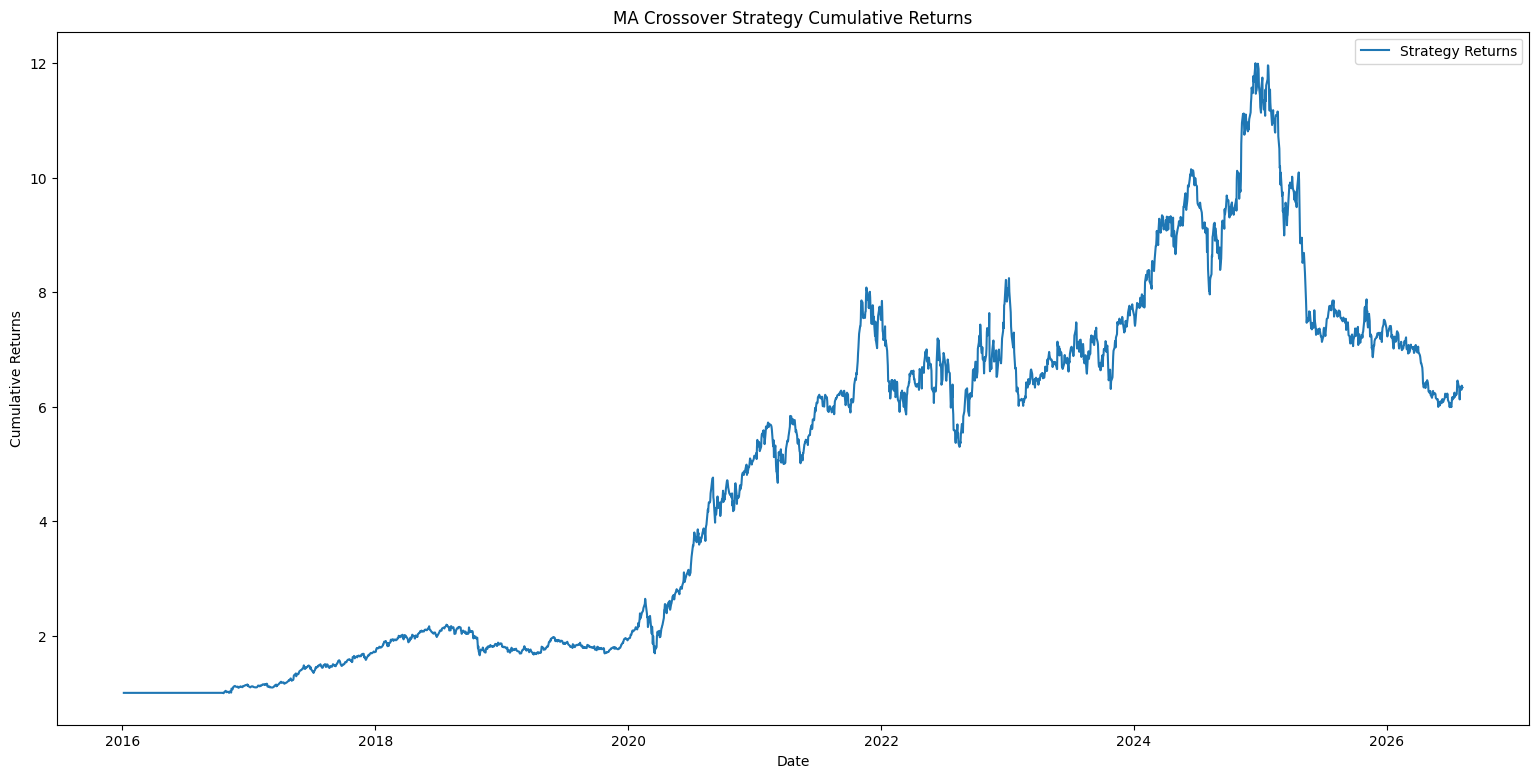

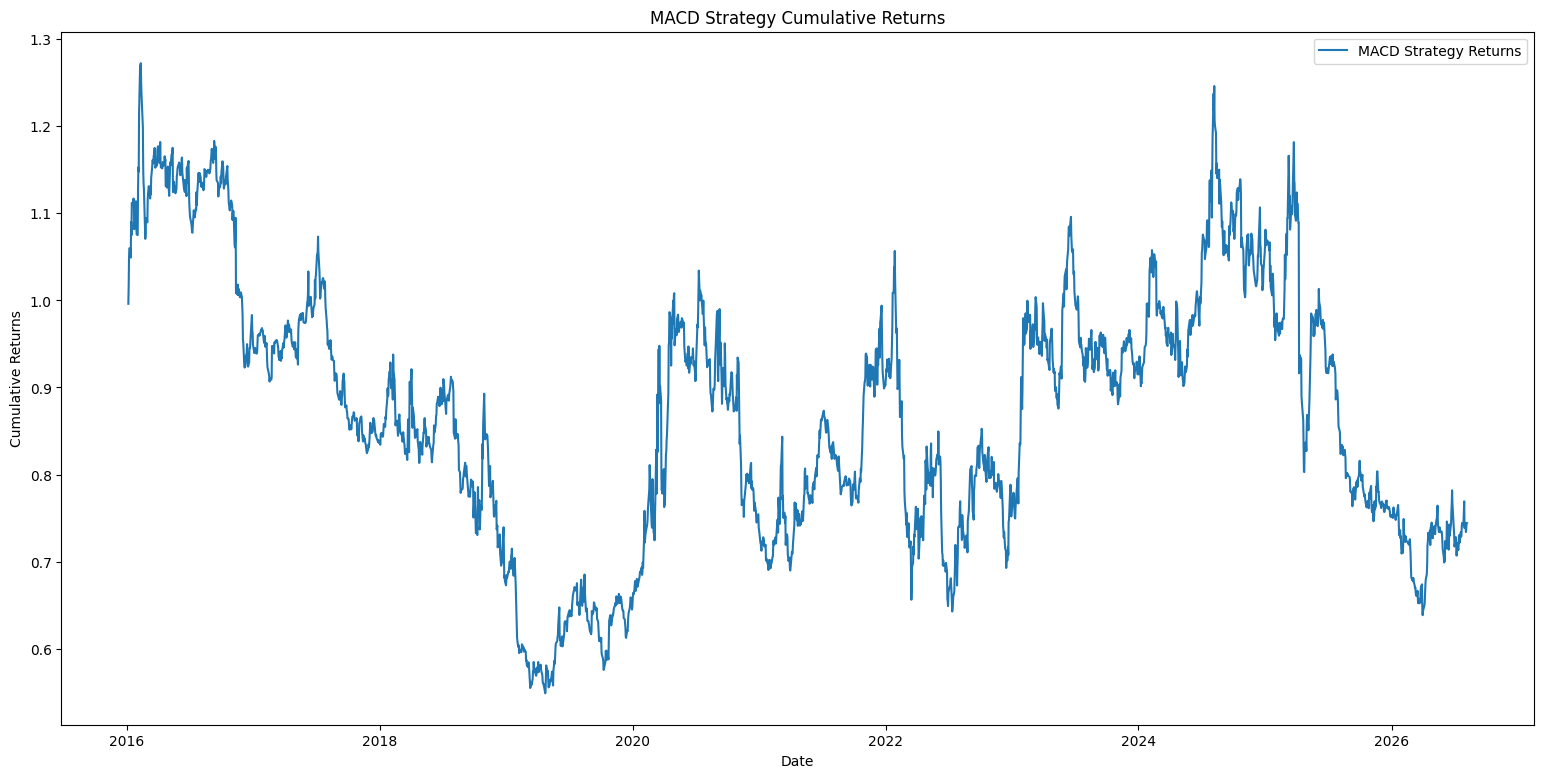

In [20]:
# Trend Following Trading Strategy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.trend import MACD

tickers = ["TSLA", "NVDA", "AMZN", "MSFT"]
data = yf.download(tickers, start='2016-01-01')['Close']

short_window = 50
long_window = 200

for ticker in tickers:
    data[f'{ticker}_SMA50'] = data[ticker].rolling(window=short_window).mean()
    data[f'{ticker}_SMA200'] = data[ticker].rolling(window=long_window).mean()

signals = pd.DataFrame(index=data.index)

# Generating MA crossover signals
for ticker in tickers:
    signals[f'{ticker}_Signal'] = 0
    signals.loc[data[f'{ticker}_SMA50'] > data[f'{ticker}_SMA200'], f'{ticker}_Signal'] = 1
    signals.loc[data[f'{ticker}_SMA50'] < data[f'{ticker}_SMA200'], f'{ticker}_Signal'] = -1

target = 'TSLA'
plt.figure(figsize=(19, 9))
plt.plot(data.index, data[target], label=f'{target} Price', alpha=.5)
plt.plot(data.index, data[f'{target}_SMA50'], label='50-day SMA', alpha=.8)
plt.plot(data.index, data[f'{target}_SMA200'], label='200-day SMA', alpha=.8)

golden_cross = (signals[f'{target}_Signal'].diff() == 2)
death_cross = (signals[f'{target}_Signal'].diff() == -2)

plt.scatter(data.index[golden_cross], data[target][golden_cross], marker='^', color='g', s=100, label='Golden Cross')
plt.scatter(data.index[death_cross], data[target][death_cross], marker='v', color='r', s=100, label='Death Cross')
plt.title(f'{target} Trend Following Based on MA Crossover')
plt.legend()
plt.show()


# Backtesting MA Crossover Strategy
returns = data[tickers].pct_change()
strategy_returns = pd.DataFrame(index=returns.index)

for ticker in tickers:
    sig = signals[f'{ticker}_Signal'].shift(1)
    strategy_returns[ticker] = sig * returns[ticker]

# portfolio level: equal weight across assets
portfolio_returns = strategy_returns.mean(axis=1)
cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(19, 9))
plt.plot(cumulative_returns, label='Strategy Returns')
plt.title('MA Crossover Strategy Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()


# EMA calculation
signals_ema = pd.DataFrame(index=data.index)
for ticker in tickers:
    data[f'{ticker}_EMA50'] = data[ticker].ewm(span=50, adjust=False).mean()
    data[f'{ticker}_EMA200'] = data[ticker].ewm(span=200, adjust=False).mean()
    signals_ema[f'{ticker}_Signal'] = 0
    signals_ema.loc[data[f'{ticker}_EMA50'] > data[f'{ticker}_EMA200'], f'{ticker}_Signal'] = 1
    signals_ema.loc[data[f'{ticker}_EMA50'] < data[f'{ticker}_EMA200'], f'{ticker}_Signal'] = -1

# MACD calculation
macd_dict = {}
signals_macd = pd.DataFrame(index=data.index)

for ticker in tickers:
    macd_indicator = MACD(data[ticker], window_slow=26, window_fast=12, window_sign=9)
    data[f'{ticker}_MACD'] = macd_indicator.macd()
    data[f'{ticker}_Signal_Line'] = macd_indicator.macd_signal()
    macd_dict[ticker] = macd_indicator
    # Generate signals
    signals_macd[f'{ticker}_Signal'] = np.where(data[f'{ticker}_MACD'] > data[f'{ticker}_Signal_Line'], 1, -1)

# Backtesting
strategy_returns_macd = pd.DataFrame(index=data.index)
for ticker in tickers:
    signal = signals_macd[f'{ticker}_Signal'].shift(1)
    strategy_returns_macd[ticker] = signal * returns[ticker]

portfolio_returns_macd = strategy_returns_macd.mean(axis=1)
cum_returns_macd = (1 + portfolio_returns_macd).cumprod()

plt.figure(figsize=(19, 9))
plt.plot(cum_returns_macd, label='MACD Strategy Returns')
plt.title('MACD Strategy Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

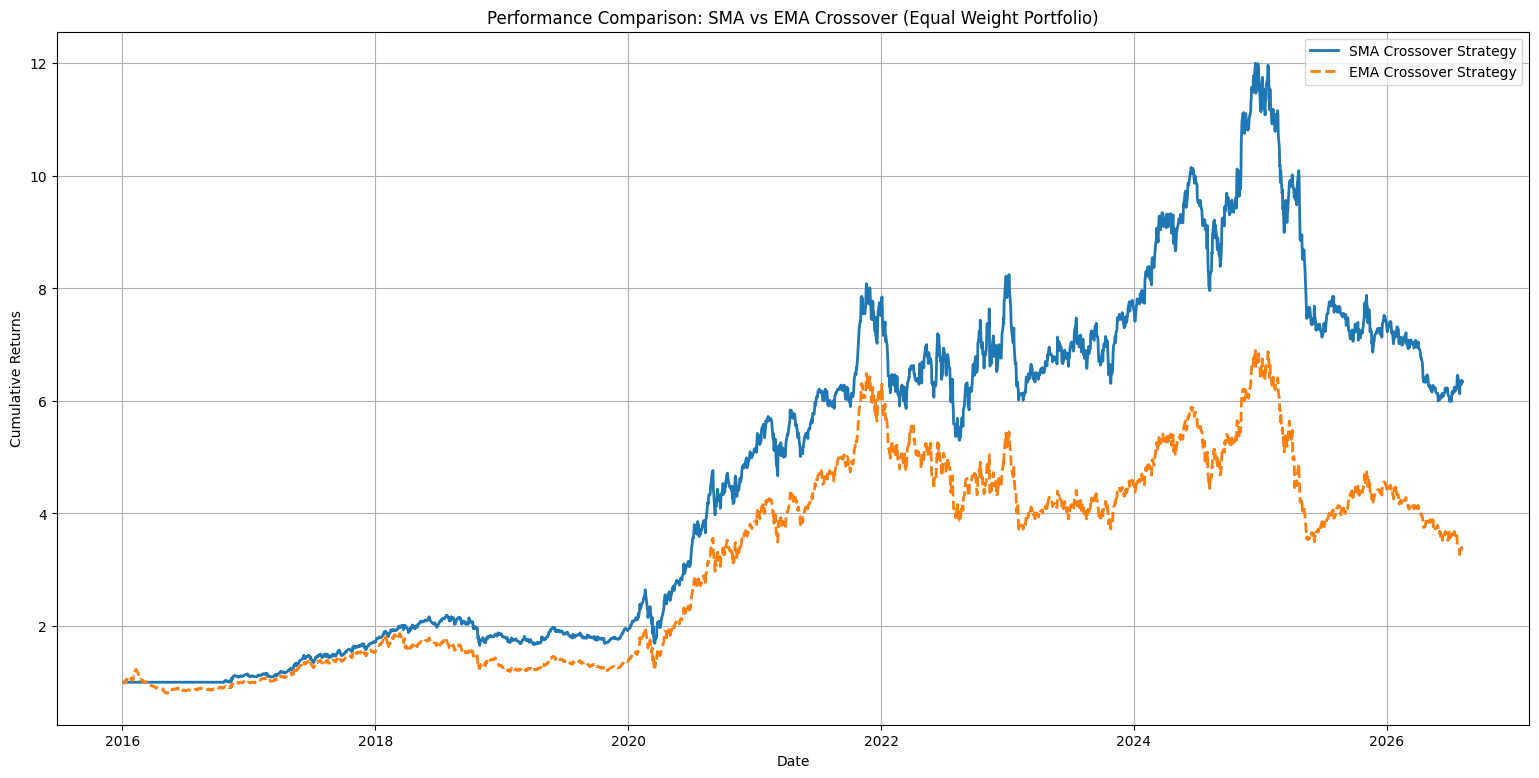

Final SMA Portfolio Value: 6.34
Final EMA Portfolio Value: 3.38


In [21]:
# Compare SMA vs EMA Strategy Performance
returns = data[tickers].pct_change()

# 1. Calculate SMA Strategy Returns
sma_strat_returns = pd.DataFrame(index=returns.index)
for ticker in tickers:
    # signals were generated in the previous cell based on SMA
    sma_sig = signals[f'{ticker}_Signal'].shift(1)
    sma_strat_returns[ticker] = sma_sig * returns[ticker]

# 2. Calculate EMA Strategy Returns
ema_strat_returns = pd.DataFrame(index=returns.index)
for ticker in tickers:
    # signals_ema were generated in the previous cell based on EMA
    ema_sig = signals_ema[f'{ticker}_Signal'].shift(1)
    ema_strat_returns[ticker] = ema_sig * returns[ticker]

# Portfolio level (Equal Weight)
portfolio_sma = (1 + sma_strat_returns.mean(axis=1)).cumprod()
portfolio_ema = (1 + ema_strat_returns.mean(axis=1)).cumprod()

# Plot Comparison
plt.figure(figsize=(19, 9))
plt.plot(portfolio_sma, label='SMA Crossover Strategy', linewidth=2)
plt.plot(portfolio_ema, label='EMA Crossover Strategy', linewidth=2, linestyle='--')
plt.title('Performance Comparison: SMA vs EMA Crossover (Equal Weight Portfolio)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final SMA Portfolio Value: {portfolio_sma.iloc[-1]:.2f}")
print(f"Final EMA Portfolio Value: {portfolio_ema.iloc[-1]:.2f}")

Positions Sample:
                TSLA      NVDA      AMZN      MSFT
Date                                              
2026-08-03 -0.032449  0.045989  0.031491 -0.032615
2026-08-04 -0.032509  0.045242  0.031012 -0.032641
2026-08-05 -0.032559  0.045452  0.030862 -0.032737
2026-08-06 -0.033608  0.045588  0.030867 -0.032718
2026-08-07 -0.032800  0.047208  0.030946 -0.032693


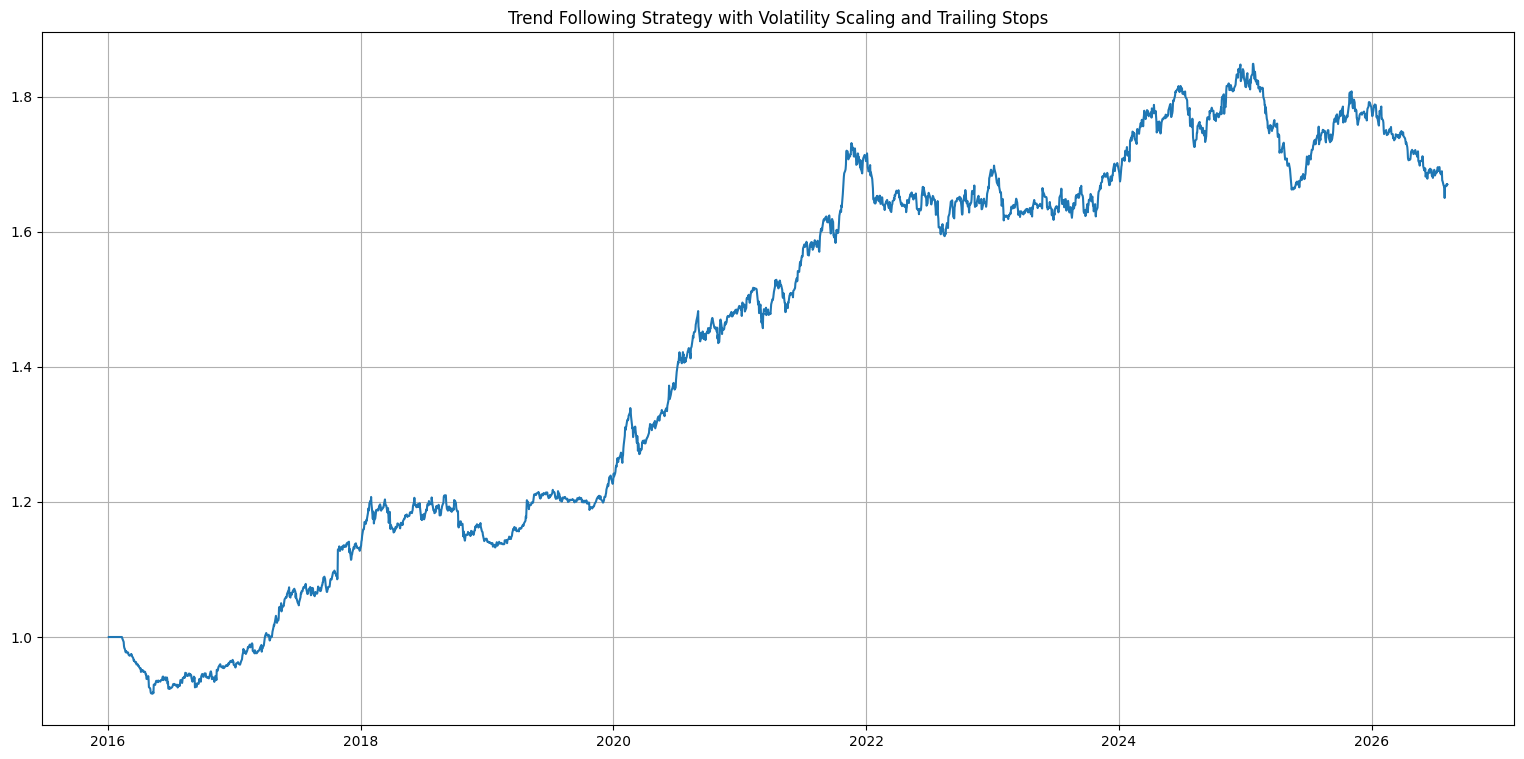

Total Return: 67.01%
Annualized Return:  4.97%
Annualized Volatility: 6.15%
Sharpe Ratio:  0.82
Max Drawdown: -10.75%


/tmp/ipykernel_2933/131735075.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_return = cumulative_strategy_returns[-1]-1


In [22]:
# Measuring Trend Strength with ADX. Vals above 25 indicate strong trend
!pip install ta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.trend import ADXIndicator
from ta.volatility import AverageTrueRange

adx_signals = pd.DataFrame(index=data.index)

for ticker in tickers:
    # ADX requires High, Low, and Close. Using rolling windows as proxies since OHLC might be missing.
    high_p = data[ticker].rolling(window=14).max()
    low_p = data[ticker].rolling(window=14).min()
    adx_obj = ADXIndicator(high=high_p, low=low_p, close=data[ticker], window=14)
    data[f'{ticker}_ADX'] = adx_obj.adx()
    adx_signals[f'{ticker}_Signal'] = np.where(data[f'{ticker}_ADX'] > 25, 1, 0)

# Combining Multiple Indicators for Robust Signals
combined_signals = pd.DataFrame(index=data.index)
for ticker in tickers:
    ma_signal = signals_ema[f'{ticker}_Signal']
    adx_mask = adx_signals[f'{ticker}_Signal'] == 1
    combined_signals[f'{ticker}_Signal'] = np.where(adx_mask, ma_signal, 0) #if ADX<25, no signal nott executed(no trade)

# Position Sizing based on volatility
returns = data[tickers].pct_change()
volatility = returns.rolling(window=20).std() * np.sqrt(252)
risk_target = .02
positions = pd.DataFrame(index=data.index)

for ticker in tickers:
    pos_size = (risk_target / volatility[ticker]).clip(upper=1)
    signal = combined_signals[f'{ticker}_Signal']
    positions[ticker] = signal * pos_size

positions = positions.fillna(0)
print("Positions Sample:")
print(positions.tail())

# Trailing Stops using ATR
atr_period = 14
trail_factor = 3
trailing_stops = pd.DataFrame(index=data.index)

for ticker in tickers:
    high_p = data[ticker].rolling(window=atr_period).max()
    low_p = data[ticker].rolling(window=atr_period).min()
    atr_obj = AverageTrueRange(high=high_p, low=low_p, close=data[ticker], window=atr_period)
    atr_values = atr_obj.average_true_range()

    # Logic to identify entry points to set stop levels
    entry_price = data[ticker].where((positions[ticker] != 0) & (positions[ticker].shift(1) == 0)).ffill()
    stop_price = entry_price - (trail_factor * atr_values)
    trailing_stops[ticker] = stop_price.ffill()

# Backtest Execution
portfolio_positions = positions.copy()
for ticker in tickers:
    # Exit position if price hits trailing stop
    exit_condition = data[ticker] < trailing_stops[ticker]
    portfolio_positions.loc[exit_condition, ticker] = 0

strategy_returns = (portfolio_positions.shift(1) * returns).sum(axis=1)
cumulative_strategy_returns = (1 + strategy_returns).cumprod()

plt.figure(figsize=(19, 9))
plt.plot(cumulative_strategy_returns)
plt.title('Trend Following Strategy with Volatility Scaling and Trailing Stops')
plt.grid(True)
plt.show()

#  Performance Metrics and Evaluation
#  Calculate key statistics just as in previous chapters

total_return = cumulative_strategy_returns[-1]-1
print(f'Total Return:{total_return * 100: .2f}%')

daily_strategy_returns = strategy_returns.dropna()
annualized_return = (1+ total_return) ** (252/len(daily_strategy_returns))-1
print(f'Annualized Return: {annualized_return * 100: .2f}%')

annualized_volatility = daily_strategy_returns.std() * np.sqrt(252)
print(f'Annualized Volatility: {annualized_volatility * 100:.2f}%')

sharpe_ratio = (daily_strategy_returns.mean() / daily_strategy_returns.std()) * np.sqrt(252)
print(f'Sharpe Ratio: {sharpe_ratio: .2f}')

rolling_max = cumulative_strategy_returns.cummax()
drawdown = (cumulative_strategy_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print(f'Max Drawdown: {max_drawdown * 100:.2f}%')

/tmp/ipykernel_2933/3635725617.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2016-01-01')
[*********************100%***********************]  1 of 1 completed


Price            Close      EMA200  Trend
Date                                     
2026-08-03  322.079987  389.814070     -1
2026-08-04  327.350006  389.192537     -1
2026-08-05  321.549988  388.519477     -1
2026-08-06  319.529999  387.833014     -1
2026-08-07  328.579987  387.243432     -1
Price            Close  Rolling_High  Rolling_Low  Retracement
Date                                                          
2026-08-03  322.079987    407.760010   298.320007     0.079646
2026-08-04  327.350006    407.760010   298.320007     0.097312
2026-08-05  321.549988    407.760010   298.320007     0.077869
2026-08-06  319.529999    407.760010   298.320007     0.071098
2026-08-07  328.579987    396.179993   298.320007     0.101435
Price            Close  Retracement       EMA20  Entry
Date                                                  
2026-07-13  394.760010     0.071808  402.915319      0
2026-07-14  396.179993     0.068469  402.273859      0
2026-07-15  394.459991     0.072514  401.5296

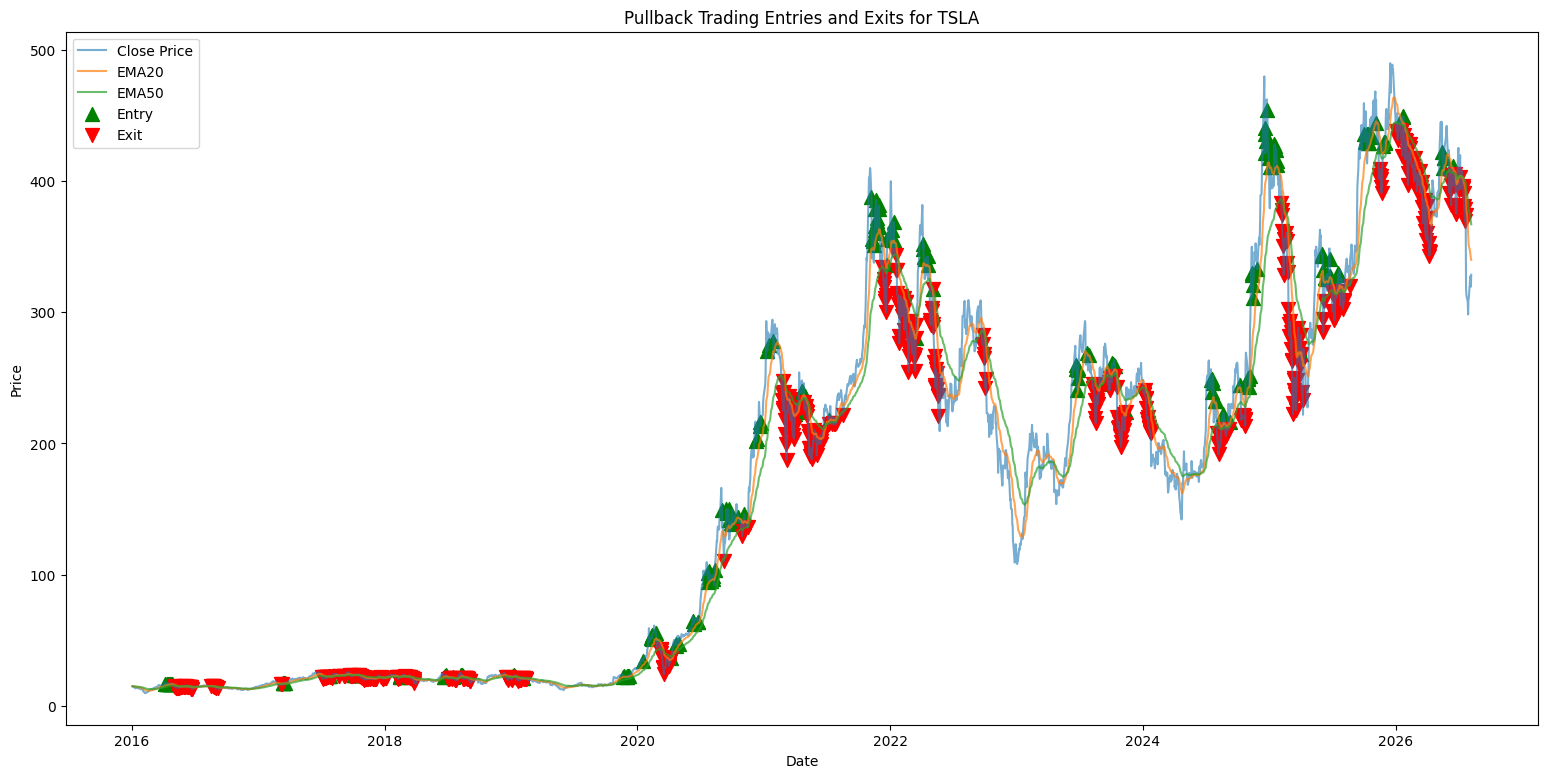

Price       Entry  Exit  Position
Date                             
2026-07-13      0     1         0
2026-07-14      0     1         0
2026-07-15      0     1         0
2026-07-16      0     1         0
2026-07-17      0     1         0
2026-07-20      0     1         0
2026-07-21      0     1         0
2026-07-22      0     1         0
2026-07-23      0     0         0
2026-07-24      0     0         0
2026-07-27      0     0         0
2026-07-28      0     0         0
2026-07-29      0     0         0
2026-07-30      0     0         0
2026-07-31      0     0         0
2026-08-03      0     0         0
2026-08-04      0     0         0
2026-08-05      0     0         0
2026-08-06      0     0         0
2026-08-07      0     0         0


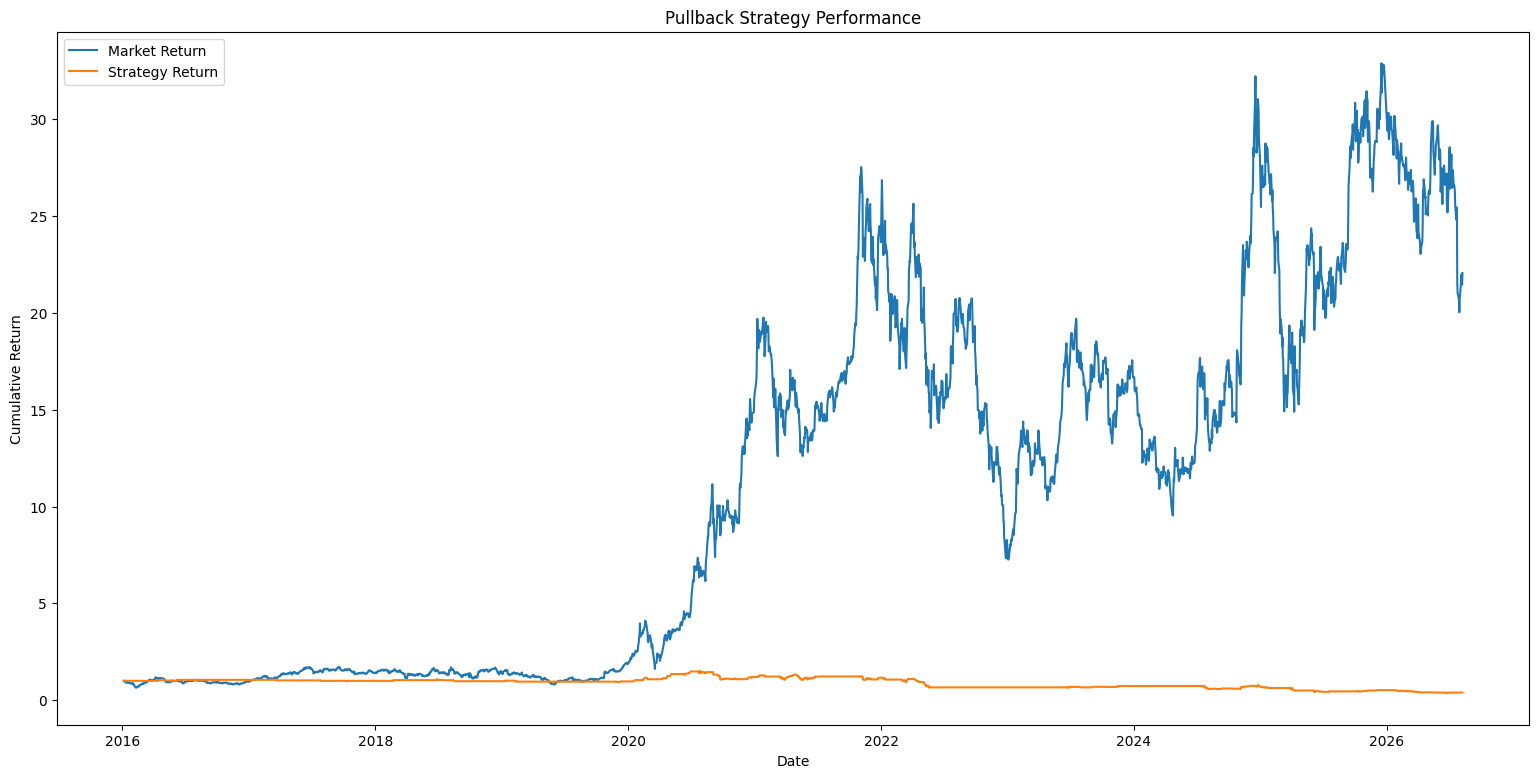

In [23]:
#  Pull Back Trading Strategy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.trend import MACD

ticker = "TSLA"
data = yf.download(ticker, start='2016-01-01')
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

data['EMA50'] = data['Close'].ewm(span=50, adjust=False).mean()
data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()

data['Trend'] = np.where(data['EMA50'] > data['EMA200'], 1, -1)
print(data[['Close', 'EMA200', 'Trend']].tail())

#  detecting pullbacks within a trend

lookback = 20

data['Rolling_High'] = data['Close'].rolling(window=lookback).max()
data['Rolling_Low'] = data['Close'].rolling(window=lookback).min()

data['Retracement'] = np.where(
    data['Trend'] ==1,
    (data['Rolling_High'] - data['Close']) / data['Rolling_High'],
    (data['Close'] - data['Rolling_Low']) / data['Rolling_Low']
)
print(data[['Close','Rolling_High', 'Rolling_Low', 'Retracement']].tail())

# Entry signal using EMA20 Bounce on pullback

data['EMA20'] = data['Close'].ewm(span=20, adjust=False).mean()

# pullback entry: trend is up, retracement between 5% and 15%, price closes above EMA20
data['Entry'] = np.where(
    (data['Trend'] == 1) & (data['Retracement'] >= .05) & (data['Retracement'] <= .15) & (data['Close'] > data['EMA20']),
    1,0
)
print(data[['Close', 'Retracement', 'EMA20', 'Entry']].tail(20))

data['Exit'] = np.where((data['Trend'] ==1) & (data['Close'] < data['EMA50']),
                        1,0
                        )
print(data[['Close', 'EMA50','Exit']].tail(20))

plt.figure(figsize=(19,9))
plt.plot(data.index, data['Close'], label='Close Price', alpha=.6)
plt.plot(data.index, data['EMA20'], label='EMA20', alpha=.7)
plt.plot(data.index, data['EMA50'], label='EMA50', alpha=.7)
entry_points = data[data['Entry'] == 1]
exit_points = data[data['Exit'] == 1]

plt.scatter(entry_points.index, entry_points['Close'], marker='^', color='g', s=100, label="Entry")
plt.scatter(exit_points.index, exit_points['Close'], marker='v', color='r', s=100, label="Exit")

plt.title(f'Pullback Trading Entries and Exits for {ticker}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#  Automating trade signals and positions
data['Position'] = 0

for i in range(1, len(data)):
  if data['Entry'].iloc[i] == 1:
    data.at[data.index[i], 'Position'] = 1
  elif data['Exit'].iloc[i] == 1:
    data.at[data.index[i], 'Position'] = data['Position'].iloc[i-1]
print(data[['Entry', 'Exit', 'Position']].tail(20))

data['Market_Return'] = data['Close'].pct_change()
data['Strategy_Return'] = data['Market_Return']*data['Position'].shift(1)

data['Cumulative_Market_Return'] = (1+ data['Market_Return']).cumprod()
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()

plt.figure(figsize=(19,9))
plt.plot(data.index, data['Cumulative_Market_Return'], label='Market Return')
plt.plot(data.index, data['Cumulative_Strategy_Return'], label='Strategy Return')
plt.title('Pullback Strategy Performance')
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

Price            Close  Entry  Entry_RSI        RSI
Date                                               
2026-08-03  322.079987      0          0  36.827827
2026-08-04  327.350006      0          0  39.211731
2026-08-05  321.549988      0          0  37.533011
2026-08-06  319.529999      0          0  36.939865
2026-08-07  328.579987      0          0  41.407465
Price       Entry_RSI  Entry_Volume     Volume  Volume_MA20
Date                                                       
2026-07-13          0             0   32809200   45792870.0
2026-07-14          0             0   23385000   43786395.0
2026-07-15          0             0   31549800   43082860.0
2026-07-16          0             0   29269100   42533540.0
2026-07-17          0             0   31394600   41926555.0
2026-07-20          0             0   33901500   40702395.0
2026-07-21          0             0   32735300   39948185.0
2026-07-22          0             0   30646100   38959480.0
2026-07-23          0             0 

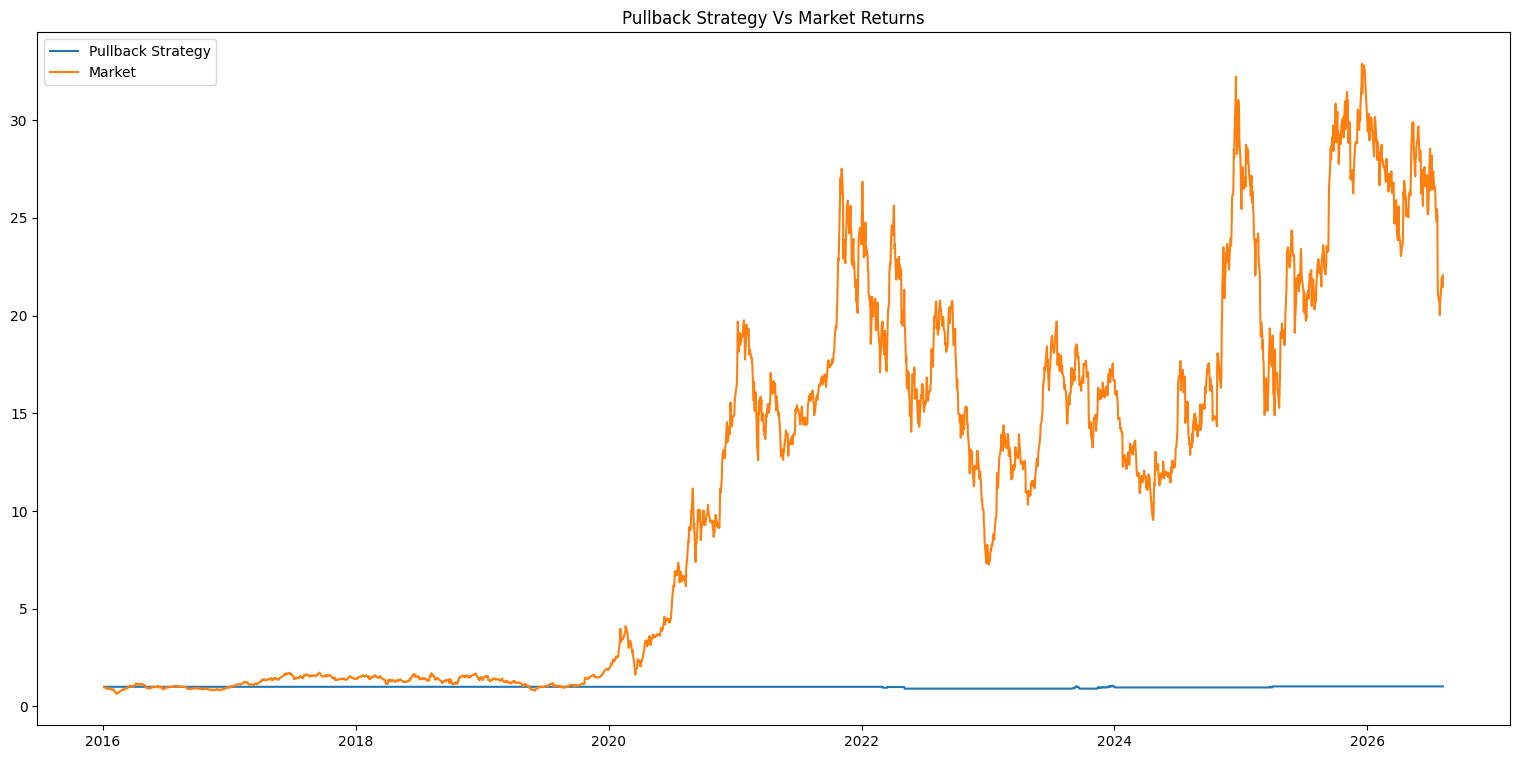

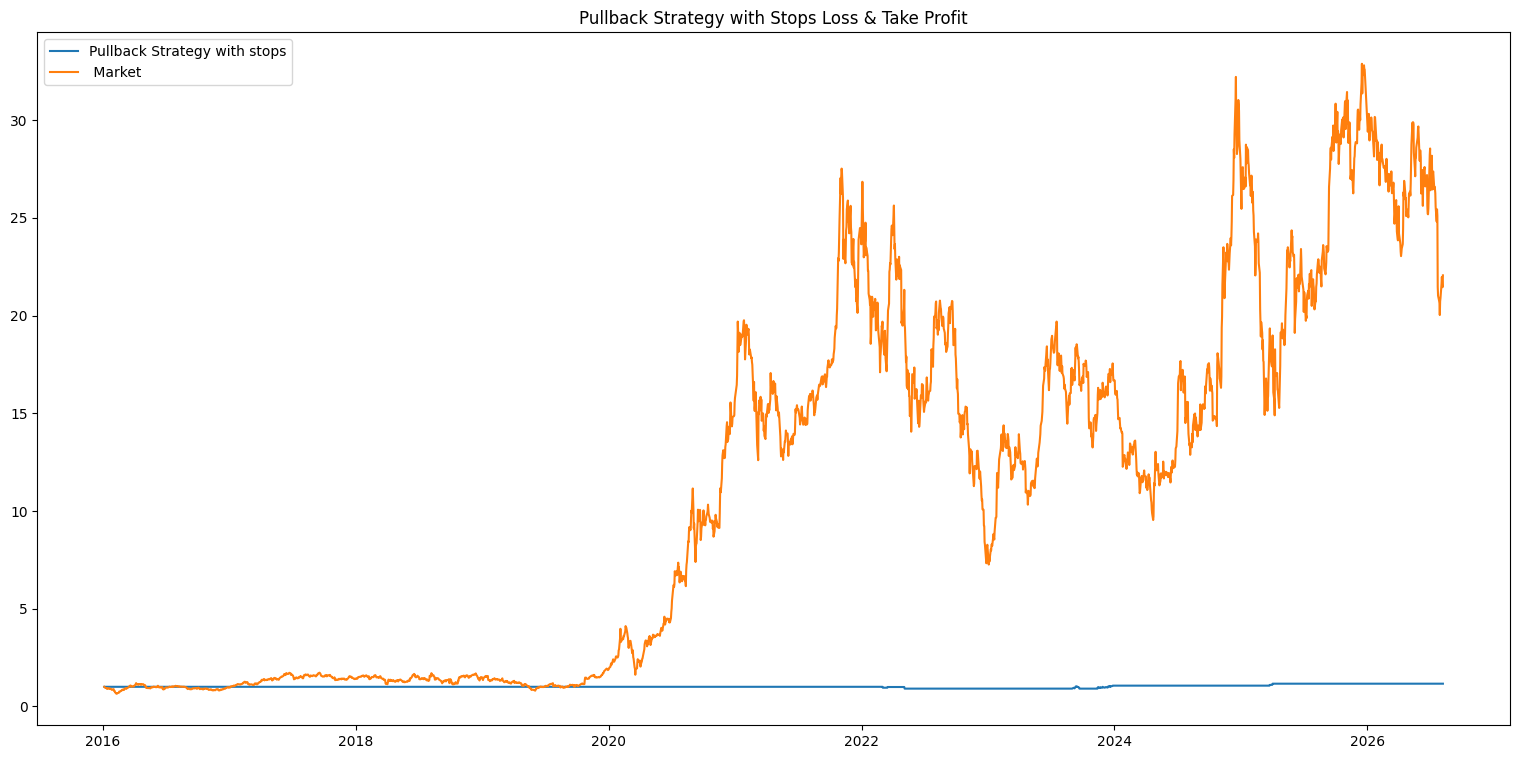

In [24]:
!pip install ta
from ta.momentum import RSIIndicator

rsi = RSIIndicator(close=data['Close'], window=14)
data['RSI'] = rsi.rsi()

data['Entry_RSI'] = np.where((data['Trend'] == 1) & (data['Retracement']>= .05) & (data['Retracement'] <= .15) & (data['Close'] > data['EMA20']) & (data['RSI'] < 50), 1,0)
print(data[['Close', 'Entry', 'Entry_RSI', 'RSI']].tail())

data['Volume_MA20'] = data['Volume'].rolling(window=20).mean()
data['Entry_Volume'] = np.where((data['Entry_RSI'] == 1) & (data['Volume'] > data['Volume_MA20']),1, 0 )
print(data[['Entry_RSI', 'Entry_Volume', 'Volume', 'Volume_MA20']].tail(20))

#  Backtesting

data['Position'] = 0

for i in range(1, len(data)):
  if data['Entry_Volume'].iloc[i] ==1:
    data.at[data.index[i], 'Position'] = 1
  elif data['Exit'].iloc[i] == 1:
    data.at[data.index[i], 'Position'] = 0
  else:
    data.at[data.index[i], 'Position'] = data['Position'].iloc[i-1]

data['Strategy_Return'] = data['Market_Return'] * data['Position'].shift(1)
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()

plt.figure(figsize=(19,9))
plt.plot(data['Cumulative_Strategy_Return'], label='Pullback Strategy')
plt.plot(data['Cumulative_Market_Return'], label='Market')
plt.title('Pullback Strategy Vs Market Returns')
plt.legend()
plt.show()




stop_loss_pct = .07
take_profit_pct = .15

entry_price = 0
positions = []
stop_losses = []
take_profits = []
data['Trade'] = 0

for i in range(len(data)):
  if data['Entry_Volume'].iloc[i] == 1 and (len(positions) == 0 or positions[-1] == 0):
    entry_price = data['Close'].iloc[i]
    stop_losses.append(entry_price * (1 - stop_loss_pct))
    take_profits.append(entry_price * (1 + take_profit_pct))
    positions.append(1)
    data.at[data.index[i], 'Trade'] = 1

  elif len(positions) > 0 and positions[-1] == 1:

    current_price = data['Close'].iloc[i]
    if current_price <= stop_losses[-1] or current_price >= take_profits[-1] or data['Exit'].iloc[i] == 1:
      positions.append(0)
      data.at[data.index[i],'Trade'] = 0
    else:
      positions.append(1)
      data.at[data.index[i], 'Trade'] = 1
  else:
    positions.append(0)
    data.at[data.index[i], 'Trade'] = 0

data['Trade'] = positions

data['Strategy_Return'] = data['Market_Return'] * data['Trade'].shift(1)
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()

plt.figure(figsize=(19,9))
plt.plot(data['Cumulative_Strategy_Return'], label='Pullback Strategy with stops')
plt.plot(data['Cumulative_Market_Return'], label= ' Market')
plt.title('Pullback Strategy with Stops Loss & Take Profit')
plt.legend()
plt.show()